# Workshop 2 · Clasificación de recurrencia tiroidea

**Fundamentos de Aprendizaje Automático · 2026-2**

**Integrantes:** Cristian Cabezas, Mateo Lopera y Juanes Villada.

Este notebook compara KNN, árbol de decisión, Random Forest y Gradient Boosting
para predecir `Recurred` (`Yes = 1`, recurrencia; `No = 0`, sin recurrencia registrada).
Incluye un predictor trivial como referencia, pipelines sin fuga de datos y una
evaluación final separada de la selección. El público es académico: los resultados
permiten discutir metodología, no definir decisiones clínicas.

**Adaptación del planteamiento (punto 1).** Aunque el taller habla de diagnóstico,
la fuente original describe **recurrencia de cáncer diferenciado de tiroides** en
383 pacientes. `Response` se excluye porque representa respuesta al tratamiento y
podría ser posterior al momento de predicción. Conservar las demás variables
no garantiza que todas estuvieran disponibles al inicio: su temporalidad requiere
confirmación antes de cualquier uso fuera del ejercicio.

Fuente: [Kaggle, Thyroid Disease Data, versión 1](https://www.kaggle.com/datasets/jainaru/thyroid-disease-data/data).
Documentación original: [Borzooei y Tarokhian (2023), UCI, DOI 10.24432/C5632J](https://archive.ics.uci.edu/dataset/915/differentiated+thyroid+cancer+recurrence).
Consultadas el 7 de septiembre de 2026. El archivo original y su SHA-256 se verifican
al cargarlo; las decisiones de limpieza se muestran antes de entrenar.

**Ruta de lectura:** preparación y auditoría → partición → EDA sobre train →
pipelines → comparación train/validación → selección congelada → test → CV →
conclusiones y sustentación. Ejecutar todas las celdas de arriba abajo.

## Resultado verificado

**Modelo seleccionado en validación: Gradient Boosting.** En test, Recall **0.800**, Precision **0.923** y F1 **0.857**: 12 recurrencias identificadas de 15, tres falsos negativos y un falso positivo. En cinco folds de entrenamiento, Recall **0.771 ± 0.089**. Estos resultados describen la muestra estudiada; no constituyen validación clínica.

La selección se mantuvo aunque Random Forest alcanzó mayor Recall en test. Las celdas siguientes explican el desempate en validación, la separación por perfiles y las limitaciones del dataset.

**Adaptación de los puntos 3, 7 y 8.** Para explorar dos columnas cuantitativas,
se usa la edad original y un conteo derivado de respuestas afirmativas en dos
campos de antecedentes, exclusivamente en entrenamiento. El conteo no modifica
los predictores ni las particiones; su definición, limitaciones e IQR se detallan
en el EDA. Se conserva el [enunciado original](enunciado/Workshop2_ML.pdf) intacto
y la [documentación del taller](README.md) explica esta correspondencia. Esta
adaptación académica es explícita; no se presenta como aprobación del profesor.


## Entorno reproducible y rutas

En local, usar Python 3.12 e instalar `requirements.txt` según el README de esta
carpeta. Abrir el notebook desde la raíz del repositorio o desde `workshop_2/`.
En Colab se puede subir únicamente este notebook: la primera celda instala las
dependencias analíticas fijadas y la carga descarga el CSV público si falta.
Usar una sesión nueva de Colab para evitar módulos importados con otras versiones.
Los reportes y figuras se guardan bajo `reportes/` y `figuras/`.

In [1]:
import os
import sys
import subprocess

DEPENDENCIAS = [
    "numpy==2.2.6", "pandas==2.3.3", "scipy==1.16.3",
    "scikit-learn==1.7.2", "matplotlib==3.10.7", "seaborn==0.13.2",
]
ES_COLAB = "google.colab" in sys.modules or bool(os.environ.get("COLAB_RELEASE_TAG"))
if ES_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *DEPENDENCIAS])
print("Entorno:", "Google Colab" if ES_COLAB else "local", "| Python", sys.version.split()[0])

Entorno: local | Python 3.12.14


In [2]:
from pathlib import Path
from io import BytesIO
from urllib.request import Request, urlopen
from zipfile import ZipFile
from hashlib import sha256
from datetime import datetime, timezone
from time import perf_counter
from importlib.metadata import version
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sklearn import set_config
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, make_scorer,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.tree import DecisionTreeClassifier

SEED = 42
np.random.seed(SEED)
set_config(enable_metadata_routing=False)
pd.set_option("display.max_columns", 22)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.spines.top": False,
                     "axes.spines.right": False})

BASE = Path.cwd()
repo_workshop = BASE / "workshop_2"
if repo_workshop.is_dir():
    BASE = repo_workshop
DATA_DIR = BASE / "data"
REPORT_DIR = BASE / "reportes"
FIG_DIR = BASE / "figuras"
for folder in (DATA_DIR, REPORT_DIR, FIG_DIR):
    folder.mkdir(parents=True, exist_ok=True)

def guardar_figura(fig, nombre):
    fig.savefig(FIG_DIR / f"clasificacion_{nombre}.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

versiones = {name: version(name) for name in
             ("numpy", "pandas", "scipy", "scikit-learn", "matplotlib", "seaborn")}
display(pd.Series(versiones, name="Versión instalada").to_frame())
print("Carpeta de trabajo:", BASE)

,Versión instalada
numpy,2.2.6
pandas,2.3.3
scipy,1.16.3
scikit-learn,1.7.2
matplotlib,3.10.7
seaborn,0.13.2


Carpeta de trabajo: S:\Github\Workshop_1\workshop_2


## Datos: procedencia y auditoría (puntos 1–6)

Se conserva el archivo descargado sin modificar. La limpieza se realiza sobre
una copia en memoria. La descarga está fijada a la **versión 1 de Kaggle**; si no
hay acceso a Internet, descargar manualmente esa versión y colocar
`Thyroid_Diff.csv` en `data/`. El hash evita ejecutar silenciosamente otra versión.

In [3]:
DATASET_URL = "https://www.kaggle.com/datasets/jainaru/thyroid-disease-data/data"
DOWNLOAD_URL = "https://www.kaggle.com/api/v1/datasets/download/jainaru/thyroid-disease-data?datasetVersionNumber=1"
EXPECTED_SHA256 = "a2c65f7c8fa0e78a65aa4946961aafd45218c92760d10375fe2c778045c97b44"
CSV_PATH = DATA_DIR / "Thyroid_Diff.csv"
descargado_ahora = not CSV_PATH.exists()

if descargado_ahora:
    try:
        request = Request(DOWNLOAD_URL, headers={"User-Agent": "Workshop2-academic-reproducibility/1.0"})
        with urlopen(request, timeout=90) as response:
            archive_bytes = response.read()
        with ZipFile(BytesIO(archive_bytes)) as archive:
            candidatos = [n for n in archive.namelist() if Path(n).name == "Thyroid_Diff.csv"]
            if len(candidatos) != 1:
                raise ValueError("El ZIP no contiene un único Thyroid_Diff.csv.")
            csv_bytes = archive.read(candidatos[0])
        if sha256(csv_bytes).hexdigest() != EXPECTED_SHA256:
            raise ValueError("El archivo descargado no coincide con el hash de la versión fijada.")
        CSV_PATH.write_bytes(csv_bytes)
    except Exception as exc:
        raise RuntimeError(
            f"No se pudo obtener el dataset verificado. Descargue la versión 1 desde {DATASET_URL} "
            f"y copie Thyroid_Diff.csv en {DATA_DIR}."
        ) from exc

data_hash = sha256(CSV_PATH.read_bytes()).hexdigest()
assert data_hash == EXPECTED_SHA256, "SHA-256 inesperado: compruebe el archivo y su versión."
raw = pd.read_csv(CSV_PATH)
assert raw.shape == (383, 17), f"Forma inesperada: {raw.shape}"
procedencia = {
    "dataset": "jainaru/thyroid-disease-data", "version_kaggle": 1,
    "archivo": CSV_PATH.name, "filas_originales": len(raw), "columnas_originales": raw.shape[1],
    "sha256": data_hash, "fuente": DATASET_URL, "descarga": DOWNLOAD_URL,
    "documentacion_original": "https://doi.org/10.24432/C5632J",
    "ejecutado_utc": datetime.now(timezone.utc).isoformat(),
    "descargado_en_esta_ejecucion": descargado_ahora, "versiones": versiones,
}
(REPORT_DIR / "clasificacion_procedencia.json").write_text(
    json.dumps(procedencia, ensure_ascii=False, indent=2), encoding="utf-8"
)
display(pd.Series({k: v for k, v in procedencia.items() if k != "versiones"}, name="Valor").to_frame())
display(raw.head())
display(raw.tail())
print("shape:", raw.shape)
raw.info()

,Valor
dataset,jainaru/thyroid-disease-data
version_kaggle,1
archivo,Thyroid_Diff.csv
filas_originales,383
columnas_originales,17
sha256,a2c65f7c8fa0e78a65aa4946961aafd45218c92760d103...
fuente,https://www.kaggle.com/datasets/jainaru/thyroi...
descarga,https://www.kaggle.com/api/v1/datasets/downloa...
documentacion_original,https://doi.org/10.24432/C5632J
ejecutado_utc,2026-09-07T23:36:10.124868+00:00


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


shape: (383, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              3

### Diccionario de las 17 variables

Las etiquetas se conservan como aparecen en el archivo; `Hx Radiothreapy` es el
nombre original, incluida su grafía. Las categorías de estadificación no se
interpretan como cantidades continuas. Este diccionario es suficiente para el
ejercicio y debe complementarse con el protocolo clínico para precisar el
momento de medición de cada campo.

In [4]:
diccionario = pd.DataFrame([
    ("Age", "Entero", "Edad del paciente (años)", "Predictor numérico"),
    ("Gender", "Categoría nominal", "Género registrado", "Predictor categórico"),
    ("Smoking", "Categoría binaria", "Tabaquismo registrado", "Predictor categórico"),
    ("Hx Smoking", "Categoría binaria", "Antecedente de tabaquismo", "Predictor categórico"),
    ("Hx Radiothreapy", "Categoría binaria", "Antecedente de radioterapia", "Predictor categórico"),
    ("Thyroid Function", "Categoría nominal", "Clasificación de función tiroidea", "Predictor categórico"),
    ("Physical Examination", "Categoría nominal", "Hallazgo de examen físico tiroideo", "Predictor categórico"),
    ("Adenopathy", "Categoría nominal", "Estado o localización de adenopatías", "Predictor categórico"),
    ("Pathology", "Categoría nominal", "Tipo histopatológico registrado", "Predictor categórico"),
    ("Focality", "Categoría nominal", "Focalidad unifocal o multifocal", "Predictor categórico"),
    ("Risk", "Categoría clínica ordenada", "Nivel de riesgo registrado", "Predictor categórico"),
    ("T", "Categoría clínica ordenada", "Categoría T de tumor primario en TNM", "Predictor categórico"),
    ("N", "Categoría clínica", "Categoría N de ganglios regionales en TNM", "Predictor categórico"),
    ("M", "Categoría clínica", "Categoría M de metástasis distante en TNM", "Predictor categórico"),
    ("Stage", "Categoría clínica ordenada", "Estadio clínico registrado", "Predictor categórico"),
    ("Response", "Categoría clínica", "Respuesta al tratamiento", "Excluida: posible información posterior"),
    ("Recurred", "Categoría binaria", "Recurrencia observada: Yes o No", "Objetivo: Yes=1, No=0"),
], columns=["Columna", "Tipo esperado", "Significado", "Uso"])
assert set(diccionario["Columna"]) == set(raw.columns)
diccionario["Tipo leído"] = diccionario["Columna"].map(raw.dtypes.astype(str))
display(diccionario)
diccionario.to_csv(REPORT_DIR / "clasificacion_diccionario.csv", index=False)

,Columna,Tipo esperado,Significado,Uso,Tipo leído
0,Age,Entero,Edad del paciente (años),Predictor numérico,int64
1,Gender,Categoría nominal,Género registrado,Predictor categórico,object
2,Smoking,Categoría binaria,Tabaquismo registrado,Predictor categórico,object
3,Hx Smoking,Categoría binaria,Antecedente de tabaquismo,Predictor categórico,object
4,Hx Radiothreapy,Categoría binaria,Antecedente de radioterapia,Predictor categórico,object
5,Thyroid Function,Categoría nominal,Clasificación de función tiroidea,Predictor categórico,object
6,Physical Examination,Categoría nominal,Hallazgo de examen físico tiroideo,Predictor categórico,object
7,Adenopathy,Categoría nominal,Estado o localización de adenopatías,Predictor categórico,object
8,Pathology,Categoría nominal,Tipo histopatológico registrado,Predictor categórico,object
9,Focality,Categoría nominal,Focalidad unifocal o multifocal,Predictor categórico,object


### Nulos, formatos y duplicados

Auditar el archivo completo permite corregir errores de formato y duplicados
exactos antes de repartir registros. Esta limpieza no estima parámetros de
modelado. Se quitan espacios periféricos y se unifican espacios repetidos en texto;
no se agrupan categorías clínicas distintas ni se inventan equivalencias.
Se muestran las posibles variantes que solo difieren en mayúsculas/minúsculas.

Se eliminan únicamente **filas idénticas en las 17 columnas originales**, como
pide el punto 5. Al no haber identificador de paciente, no se puede demostrar que
esas coincidencias sean errores; esta deduplicación es una decisión del ejercicio
y podría retirar pacientes diferentes con el mismo registro. Eliminar después de
excluir `Response` borraría observaciones que antes eran distintas: no se hace.

In [5]:
clean = raw.copy()
audit_formatos = []
for col in clean.select_dtypes(include=["object", "string"]).columns:
    original = clean[col].copy()
    normalizado = original.str.strip().str.replace(r"\s+", " ", regex=True).replace("", np.nan)
    cambios = int((original.fillna("<NA>") != normalizado.fillna("<NA>")).sum())
    clean[col] = normalizado
    variantes = clean[col].dropna().drop_duplicates().groupby(
        clean[col].dropna().drop_duplicates().str.casefold()
    ).agg(list)
    conflictos_case = [values for values in variantes if len(values) > 1]
    audit_formatos.append({"Columna": col, "Valores ajustados": cambios,
                           "Variantes de mayúsculas": str(conflictos_case)})
display(pd.DataFrame(audit_formatos))
assert all(row["Variantes de mayúsculas"] == "[]" for row in audit_formatos), (
    "Aparecieron variantes no previstas: revisar y documentar antes de continuar."
)
auditoria_nulos = pd.DataFrame({
    "Nulos originales": raw.isna().sum(), "Nulos tras formato": clean.isna().sum(),
    "% nulos tras formato": 100 * clean.isna().mean(),
})
display(auditoria_nulos)
assert clean["Recurred"].notna().all(), "No es válido imputar la etiqueta objetivo."
assert set(clean["Recurred"].unique()) == {"Yes", "No"}
assert pd.api.types.is_numeric_dtype(clean["Age"])
assert clean["Age"].dropna().between(0, 120).all(), "Revisar edades fuera del intervalo plausible."

n_duplicados = int(clean.duplicated().sum())
assert n_duplicados == 19, f"Se esperaban 19 duplicados completos, se encontraron {n_duplicados}."
clean = clean.drop_duplicates(keep="first").copy()
auditoria_limpieza = pd.DataFrame([
    {"Etapa": "Archivo original", "Filas": len(raw), "Columnas": raw.shape[1], "Filas retiradas": 0},
    {"Etapa": "Normalización determinista", "Filas": len(raw), "Columnas": raw.shape[1], "Filas retiradas": 0},
    {"Etapa": "Sin duplicados completos", "Filas": len(clean), "Columnas": clean.shape[1], "Filas retiradas": n_duplicados},
    {"Etapa": "Objetivo separado; Response excluida", "Filas": len(clean), "Columnas": clean.shape[1] - 2, "Filas retiradas": 0},
])
display(auditoria_limpieza)
auditoria_nulos.to_csv(REPORT_DIR / "clasificacion_nulos.csv")
auditoria_limpieza.to_csv(REPORT_DIR / "clasificacion_limpieza.csv", index=False)
display(Markdown(
    f"Se retiraron **{n_duplicados} duplicados completos** y quedan **{len(clean)} registros**. "
    f"Tras normalizar hay **{int(clean.isna().sum().sum())} valores nulos**. "
    "No se elimina ninguna columna por nulos. El pipeline deja una protección reproducible: "
    "mediana para edad y moda para categorías, calculadas solo en train. La mediana tolera edades "
    "extremas; la moda produce una categoría existente, aunque puede reforzar la mayoría si "
    "aparecen nulos. No se atribuye a estas imputaciones un efecto que este archivo no necesita."
))

,Columna,Valores ajustados,Variantes de mayúsculas
0,Gender,0,[]
1,Smoking,0,[]
2,Hx Smoking,0,[]
3,Hx Radiothreapy,0,[]
4,Thyroid Function,0,[]
5,Physical Examination,0,[]
6,Adenopathy,0,[]
7,Pathology,0,[]
8,Focality,0,[]
9,Risk,0,[]


,Nulos originales,Nulos tras formato,% nulos tras formato
Age,0,0,0.0000
Gender,0,0,0.0000
Smoking,0,0,0.0000
Hx Smoking,0,0,0.0000
Hx Radiothreapy,0,0,0.0000
Thyroid Function,0,0,0.0000
Physical Examination,0,0,0.0000
Adenopathy,0,0,0.0000
Pathology,0,0,0.0000
Focality,0,0,0.0000


,Etapa,Filas,Columnas,Filas retiradas
0,Archivo original,383,17,0
1,Normalización determinista,383,17,0
2,Sin duplicados completos,364,17,19
3,Objetivo separado; Response excluida,364,15,0


Se retiraron **19 duplicados completos** y quedan **364 registros**. Tras normalizar hay **0 valores nulos**. No se elimina ninguna columna por nulos. El pipeline deja una protección reproducible: mediana para edad y moda para categorías, calculadas solo en train. La mediana tolera edades extremas; la moda produce una categoría existente, aunque puede reforzar la mayoría si aparecen nulos. No se atribuye a estas imputaciones un efecto que este archivo no necesita.

## Particiones reproducibles por perfil (punto 11)

**Train** permite estimar imputación, escalamiento, categorías y parámetros del
modelo. **Validación** permite comparar modelos sin usar test para escogerlos.
**Test** se reserva para evaluar los modelos ya congelados; usarlo repetidamente
para seleccionar haría optimista su estimación.

Después de quitar `Response`, algunos registros pueden compartir todos los
predictores. No se eliminan: pueden ser observaciones distintas e incluso tener
objetivos diferentes. Se agrupan por un hash de **X**, sin el objetivo y sin
`Response`, para mantener cada perfil en un solo conjunto. Esto evita memorizar
el mismo perfil a través de las particiones, pero no demuestra independencia
entre pacientes porque no hay un identificador.

Se usa `StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=42)`: fold 0
para test, fold 1 para validación y folds 2–6 para train. Las proporciones son
aproximadamente 71/14/14: preservar grupos tiene prioridad sobre porcentajes
exactos. Se audita tamaño y balance, pero no se explora test para tomar decisiones.

In [6]:
X = clean.drop(columns=["Response", "Recurred"]).copy()
y = clean["Recurred"].map({"No": 0, "Yes": 1}).astype(int)
numeric_cols = ["Age"]
categorical_cols = [col for col in X if col not in numeric_cols]
assert len(numeric_cols) == 1 and len(categorical_cols) == 14
assert "Recurred" not in X and "Response" not in X

# SHA-256 del perfil canónico: idéntico X => idéntico grupo, incluso con distinto y.
profile_hashes = pd.Series([
    sha256(json.dumps(row, ensure_ascii=False, separators=(",", ":"),
                      default=str).encode("utf-8")).hexdigest()
    for row in X.where(X.notna(), None).itertuples(index=False, name=None)
], index=X.index, name="sha256_perfil")
assert profile_hashes.nunique() == X.drop_duplicates().shape[0], "Revisar colisión o normalización del hash."
# IDs consecutivos por primera aparición: mismos grupos, orden estable sin ordenar hashes.
groups = pd.Series(pd.factorize(profile_hashes, sort=False)[0], index=X.index, name="grupo_perfil")
perfiles = pd.DataFrame({"grupo": groups, "y": y}).groupby("grupo")["y"].agg(["size", "nunique"])
display(pd.DataFrame({"Cantidad": {
    "Perfiles únicos": groups.nunique(),
    "Perfiles con varias observaciones": int((perfiles["size"] > 1).sum()),
    "Perfiles con objetivos contradictorios": int((perfiles["nunique"] > 1).sum()),
    "Registros retenidos": len(X),
}}))

splitter = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
fold_ids = np.full(len(X), -1, dtype=int)
for fold, (_, holdout_idx) in enumerate(splitter.split(X, y, groups=groups)):
    fold_ids[holdout_idx] = fold
assert (fold_ids >= 0).all()
idx_test = np.flatnonzero(fold_ids == 0)
idx_val = np.flatnonzero(fold_ids == 1)
idx_train = np.flatnonzero(fold_ids >= 2)
indices = {"train": idx_train, "validacion": idx_val, "test": idx_test}

for a, b in [("train", "validacion"), ("train", "test"), ("validacion", "test")]:
    assert set(indices[a]).isdisjoint(indices[b])
    assert set(groups.iloc[indices[a]]).isdisjoint(groups.iloc[indices[b]])
assert len(set(np.concatenate(list(indices.values())))) == len(X)
assert all(y.iloc[idx].nunique() == 2 for idx in indices.values())

X_train, y_train = X.iloc[idx_train].copy(), y.iloc[idx_train].copy()
X_val, y_val = X.iloc[idx_val].copy(), y.iloc[idx_val].copy()
X_test, y_test = X.iloc[idx_test].copy(), y.iloc[idx_test].copy()
groups_train = groups.iloc[idx_train].copy()
particiones = pd.DataFrame([
    {"Conjunto": nombre, "Filas": len(idx), "% del total": 100 * len(idx) / len(X),
     "No (0)": int((y.iloc[idx] == 0).sum()), "Yes (1)": int((y.iloc[idx] == 1).sum()),
     "% Yes": 100 * y.iloc[idx].mean(), "Grupos": groups.iloc[idx].nunique()}
    for nombre, idx in indices.items()
]).set_index("Conjunto")
display(particiones)
particiones.to_csv(REPORT_DIR / "clasificacion_particiones.csv")
split_manifest = pd.DataFrame({
    "indice_archivo_original": X.index, "grupo_perfil": groups.to_numpy(),
    "sha256_perfil": profile_hashes.to_numpy(), "fold": fold_ids,
    "conjunto": np.where(fold_ids == 0, "test", np.where(fold_ids == 1, "validacion", "train")),
})
split_manifest.to_csv(REPORT_DIR / "clasificacion_asignacion_particiones.csv", index=False)
display(Markdown(
    "**Verificación:** ninguna fila ni perfil atraviesa conjuntos. "
    "Las observaciones con el mismo X y distinto resultado se conservan juntas: "
    "sus contradicciones son una limitación de la información disponible, no un motivo para borrar una clase."
))

,Cantidad
Perfiles únicos,356
Perfiles con varias observaciones,7
Perfiles con objetivos contradictorios,1
Registros retenidos,364


,Filas,% del total,No (0),Yes (1),% Yes,Grupos
Conjunto,,,,,,
train,261,71.7033,182,79,30.2682,254
validacion,52,14.2857,38,14,26.9231,51
test,51,14.0110,36,15,29.4118,51


**Verificación:** ninguna fila ni perfil atraviesa conjuntos. Las observaciones con el mismo X y distinto resultado se conservan juntas: sus contradicciones son una limitación de la información disponible, no un motivo para borrar una clase.

## EDA exclusivamente sobre entrenamiento (puntos 3, 7–10)

La exploración detallada comienza después de reservar validación y test.
Las asociaciones observadas son descriptivas; no prueban causas de recurrencia.
Las recomendaciones siguientes se refieren al análisis y al diseño del modelo.

### Variable derivada para completar la exploración cuantitativa

`n_antecedentes_afirmativos` suma `1[Hx Smoking = Yes] + 1[Hx Radiothreapy = Yes]`.
Cuenta cuántos de **dos campos registrados** responden afirmativamente: 0, 1 o 2.
No cuenta episodios ni tratamientos y no constituye una puntuación de riesgo;
sumar ambos indicadores tampoco supone que tengan la misma importancia clínica.
Es una cantidad discreta interpretable, distinta de asignar rangos arbitrarios
a `Risk`, `Stage` o las categorías TNM.

Se construye después de fijar las particiones y solo en una copia de train para
EDA. Se documenta aparte de las **17 variables originales**. Se mantienen los
dos antecedentes originales como predictores y el conteo queda fuera de X y
de los modelos, para conservar la comparación acordada. Una etiqueta inesperada
interrumpe la ejecución; si falta algún antecedente, el conteo queda ausente.


In [7]:
CONTEO_ANTECEDENTES = "n_antecedentes_afirmativos"
CAMPOS_ANTECEDENTES = ["Hx Smoking", "Hx Radiothreapy"]

def contar_antecedentes_afirmativos(datos):
    campos = datos.loc[:, CAMPOS_ANTECEDENTES]
    for col in CAMPOS_ANTECEDENTES:
        desconocidas = campos[col].dropna().loc[~campos[col].dropna().isin(["Yes", "No"])]
        if not desconocidas.empty:
            raise ValueError(f"Etiquetas no previstas en {col}: {desconocidas.unique().tolist()}")
    indicadores = campos.apply(lambda serie: serie.map({"No": 0, "Yes": 1}))
    # Con un campo ausente, el conteo queda ausente: nunca se sustituye por No.
    return indicadores.sum(axis=1, min_count=2).astype("Int64").rename(CONTEO_ANTECEDENTES)

conteo_antecedentes = contar_antecedentes_afirmativos(X_train)
train_eda = X_train.assign(**{CONTEO_ANTECEDENTES: conteo_antecedentes},
                           Recurred=y_train.map({0: "No", 1: "Yes"}))
assert CONTEO_ANTECEDENTES not in X_train and CONTEO_ANTECEDENTES not in X
assert conteo_antecedentes.notna().all(), "Revisar antecedentes ausentes antes de interpretar el EDA."
assert conteo_antecedentes.isin([0, 1, 2]).all()

diccionario_derivadas = pd.DataFrame([{
    "Variable": CONTEO_ANTECEDENTES,
    "Tipo": "Cuantitativa discreta derivada",
    "Definición": "1[Hx Smoking = Yes] + 1[Hx Radiothreapy = Yes]",
    "Unidad": "Campos registrados con respuesta afirmativa (de dos posibles)",
    "Dominio": "0, 1, 2; ausente si cualquiera de los dos campos falta",
    "Uso": "Solo EDA de entrenamiento: descriptivos, frecuencias, IQR y dispersión",
    "Límite": "No mide episodios, intensidad ni riesgo clínico; no es una medición original",
}])
display(diccionario_derivadas.T.rename(columns={0: "Descripción"}))
diccionario_derivadas.to_csv(REPORT_DIR / "clasificacion_diccionario_derivadas.csv", index=False)
train_eda[CAMPOS_ANTECEDENTES + [CONTEO_ANTECEDENTES]].to_csv(
    REPORT_DIR / "clasificacion_antecedentes_train.csv", index_label="indice_archivo_original"
)


,Descripción
Variable,n_antecedentes_afirmativos
Tipo,Cuantitativa discreta derivada
Definición,1[Hx Smoking = Yes] + 1[Hx Radiothreapy = Yes]
Unidad,Campos registrados con respuesta afirmativa (d...
Dominio,"0, 1, 2; ausente si cualquiera de los dos camp..."
Uso,"Solo EDA de entrenamiento: descriptivos, frecu..."
Límite,"No mide episodios, intensidad ni riesgo clínic..."


### Estadísticas descriptivas de edad y conteo derivado

In [8]:
descriptivos = train_eda.select_dtypes(include=np.number).describe()
display(descriptivos)
descriptivos.to_csv(REPORT_DIR / "clasificacion_descriptivos_train.csv")
edad = X_train["Age"]
display(Markdown(
    f"La **media de edad es {edad.mean():.1f} años**: describe el centro del grupo de entrenamiento, "
    f"no la edad de mayor riesgo. La **mediana es {edad.median():.1f} años**: la mitad de registros "
    f"tiene esa edad o menos. La **desviación estándar es {edad.std():.1f} años**, que muestra la "
    f"dispersión respecto a la media. El intervalo intercuartílico va de **{edad.quantile(.25):.1f} "
    f"a {edad.quantile(.75):.1f} años**, donde cae la mitad central de las edades. "
    "Se conserva la mediana como referencia robusta de centro y se evita extrapolar estas edades "
    "a una población clínica diferente."
))
frecuencias_antecedentes = conteo_antecedentes.value_counts().reindex([0, 1, 2], fill_value=0)
frecuencias_antecedentes.index.name = CONTEO_ANTECEDENTES
frecuencias_antecedentes = frecuencias_antecedentes.to_frame("Registros")
frecuencias_antecedentes["% train"] = 100 * frecuencias_antecedentes["Registros"] / len(X_train)
display(frecuencias_antecedentes)
frecuencias_antecedentes.to_csv(REPORT_DIR / "clasificacion_frecuencias_antecedentes_train.csv")
display(Markdown(
    f"El conteo tiene **media {conteo_antecedentes.mean():.3f}**, "
    f"**mediana {conteo_antecedentes.median():.0f}** y desviación estándar "
    f"**{conteo_antecedentes.std():.3f} campos afirmativos**. "
    f"Hay **{frecuencias_antecedentes.loc[0, 'Registros']} registros con cero**, "
    f"**{frecuencias_antecedentes.loc[1, 'Registros']} con uno** y "
    f"**{frecuencias_antecedentes.loc[2, 'Registros']} con dos**. "
    "Media y desviación describen la cantidad de campos afirmativos por registro, "
    "no una escala de gravedad. La concentración en cero motiva interpretar las "
    "frecuencias junto con los cuartiles."
))


,Age,n_antecedentes_afirmativos
count,261.0000,261.0000
mean,40.7548,0.0958
std,14.8410,0.3317
min,17.0000,0.0000
25%,29.0000,0.0000
50%,37.0000,0.0000
75%,51.0000,0.0000
max,82.0000,2.0000


La **media de edad es 40.8 años**: describe el centro del grupo de entrenamiento, no la edad de mayor riesgo. La **mediana es 37.0 años**: la mitad de registros tiene esa edad o menos. La **desviación estándar es 14.8 años**, que muestra la dispersión respecto a la media. El intervalo intercuartílico va de **29.0 a 51.0 años**, donde cae la mitad central de las edades. Se conserva la mediana como referencia robusta de centro y se evita extrapolar estas edades a una población clínica diferente.

,Registros,% train
n_antecedentes_afirmativos,,
0,239,91.5709
1,19,7.2797
2,3,1.1494


El conteo tiene **media 0.096**, **mediana 0** y desviación estándar **0.332 campos afirmativos**. Hay **239 registros con cero**, **19 con uno** y **3 con dos**. Media y desviación describen la cantidad de campos afirmativos por registro, no una escala de gravedad. La concentración en cero motiva interpretar las frecuencias junto con los cuartiles.

### IQR en edad y conteo de antecedentes (punto 7)

`Age` es la única medición numérica original. La segunda columna cuantitativa es
el conteo discreto **derivado y documentado arriba**. Así se desarrolla el método
solicitado en dos columnas sin presentar categorías clínicas codificadas como
mediciones. Esta es una adaptación transparente al dataset enlazado.

Se calculan Q1, Q3, IQR y los límites `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` solo
sobre train. Un punto fuera de los límites es una señal estadística y no demuestra
error de registro. Cuando Q1 = Q3 = 0, el IQR es cero: la regla señala cualquier
conteo positivo, aunque 1 y 2 pertenezcan al dominio válido. Por eso se acompañan
los cuartiles con frecuencias y **se conservan todos los registros**. Tampoco
se eliminan edades plausibles por rareza.


In [9]:
filas_iqr = []
mascaras_iqr = {}
for variable in ["Age", CONTEO_ANTECEDENTES]:
    valores = train_eda[variable]
    q1, q3 = valores.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior, limite_superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask_outliers = (valores < limite_inferior) | (valores > limite_superior)
    mascaras_iqr[variable] = mask_outliers
    filas_iqr.append({
        "Variable": variable, "Q1": q1, "Q3": q3, "IQR": iqr,
        "Límite inferior": limite_inferior, "Límite superior": limite_superior,
        "Outliers": int(mask_outliers.sum()), "% train": 100 * mask_outliers.mean(),
        "Mínimo": valores.min(), "Máximo": valores.max(), "Acción": "Conservar",
    })
outliers = pd.DataFrame(filas_iqr)
display(outliers)
outliers.to_csv(REPORT_DIR / "clasificacion_iqr_train.csv", index=False)
iqr_por_variable = outliers.set_index("Variable")
iqr_edad = iqr_por_variable.loc["Age"]
iqr_conteo = iqr_por_variable.loc[CONTEO_ANTECEDENTES]
display(Markdown(
    f"Se señalan **{int(iqr_edad['Outliers'])} edades** fuera de los límites "
    f"IQR [{iqr_edad['Límite inferior']:.1f}, {iqr_edad['Límite superior']:.1f}], "
    f"con rango observado {edad.min():.0f}–{edad.max():.0f} años. "
    f"En el conteo, **Q1 = Q3 = IQR = {iqr_conteo['IQR']:.0f}** y los límites "
    f"son [{iqr_conteo['Límite inferior']:.0f}, {iqr_conteo['Límite superior']:.0f}]: "
    f"la regla señala **{int(iqr_conteo['Outliers'])} registros "
    f"({iqr_conteo['% train']:.2f}% de train)** con uno o dos antecedentes afirmativos. "
    "Son valores legítimos del conteo, no errores. **Se conservan los 261 registros de train**. "
    "El caso muestra la limitación de IQR cuando una distribución discreta concentra "
    "más del 75% de sus valores en cero; las frecuencias aportan el contexto necesario. "
    "Solo la edad entra en RobustScaler para KNN. El conteo se limita al EDA y no se escala "
    "ni se incorpora a los modelos."
))


,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers,% train,Mínimo,Máximo,Acción
0,Age,29.0000,51.0000,22.0000,-4.0000,84.0000,0,0.0000,17,82,Conservar
1,n_antecedentes_afirmativos,0.0000,0.0000,0.0000,0.0000,0.0000,22,8.4291,0,2,Conservar


Se señalan **0 edades** fuera de los límites IQR [-4.0, 84.0], con rango observado 17–82 años. En el conteo, **Q1 = Q3 = IQR = 0** y los límites son [0, 0]: la regla señala **22 registros (8.43% de train)** con uno o dos antecedentes afirmativos. Son valores legítimos del conteo, no errores. **Se conservan los 261 registros de train**. El caso muestra la limitación de IQR cuando una distribución discreta concentra más del 75% de sus valores en cero; las frecuencias aportan el contexto necesario. Solo la edad entra en RobustScaler para KNN. El conteo se limita al EDA y no se escala ni se incorpora a los modelos.

### Barras: composición por tipo histopatológico

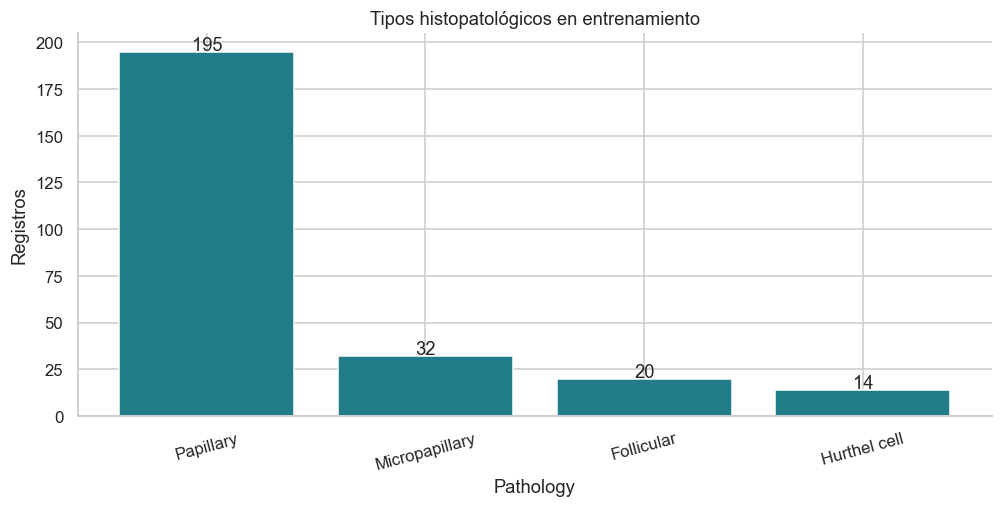

**Interpretación:** `Papillary` reúne **195 de 261 registros (74.7%)**. La categoría menos representada aporta 14 registros. **Recomendación:** conservar los tipos y revisar la cobertura por subgrupo en una validación externa; una métrica global puede ocultar errores en categorías poco frecuentes.

In [10]:
counts_pathology = X_train["Pathology"].value_counts()
fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
ax.bar(counts_pathology.index, counts_pathology.values, color="#217C8A")
ax.set(title="Tipos histopatológicos en entrenamiento", xlabel="Pathology", ylabel="Registros")
ax.tick_params(axis="x", labelrotation=15)
for i, val in enumerate(counts_pathology.values):
    ax.text(i, val + 1, str(val), ha="center")
guardar_figura(fig, "eda_barras")
display(Markdown(
    f"**Interpretación:** `{counts_pathology.index[0]}` reúne **{counts_pathology.iloc[0]} "
    f"de {len(X_train)} registros ({100 * counts_pathology.iloc[0] / len(X_train):.1f}%)**. "
    f"La categoría menos representada aporta {counts_pathology.iloc[-1]} registros. "
    "**Recomendación:** conservar los tipos y revisar la cobertura por subgrupo en una validación "
    "externa; una métrica global puede ocultar errores en categorías poco frecuentes."
))

### Pie: distribución de recurrencia

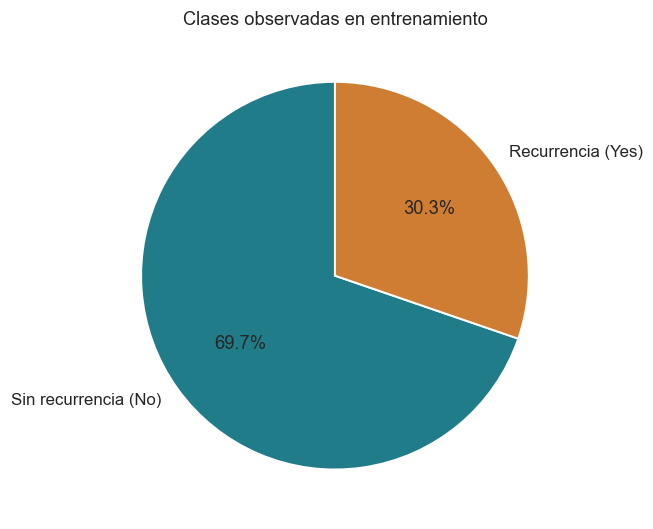

**Interpretación:** hay **79 recurrencias de 261 registros (30.3%)**. La clase mayoritaria representa 69.7%. **Recomendación:** comparar contra un predictor mayoritario y priorizar Recall positivo, acompañado de Precision y F1. Accuracy por sí sola puede parecer buena aun omitiendo recurrencias.

In [11]:
counts_target = y_train.value_counts().reindex([0, 1], fill_value=0)
fig, ax = plt.subplots(figsize=(6, 4.7), layout="constrained")
ax.pie(counts_target, labels=["Sin recurrencia (No)", "Recurrencia (Yes)"],
       autopct="%1.1f%%", startangle=90, colors=["#217C8A", "#D07D34"],
       wedgeprops={"edgecolor": "white", "linewidth": 1.3})
ax.set_title("Clases observadas en entrenamiento")
guardar_figura(fig, "eda_pie")
display(Markdown(
    f"**Interpretación:** hay **{counts_target[1]} recurrencias de {counts_target.sum()} "
    f"registros ({100 * y_train.mean():.1f}%)**. La clase mayoritaria representa "
    f"{100 * counts_target.max() / counts_target.sum():.1f}%. "
    "**Recomendación:** comparar contra un predictor mayoritario y priorizar Recall positivo, "
    "acompañado de Precision y F1. Accuracy por sí sola puede parecer buena aun omitiendo recurrencias."
))

### Histograma: distribución de edad

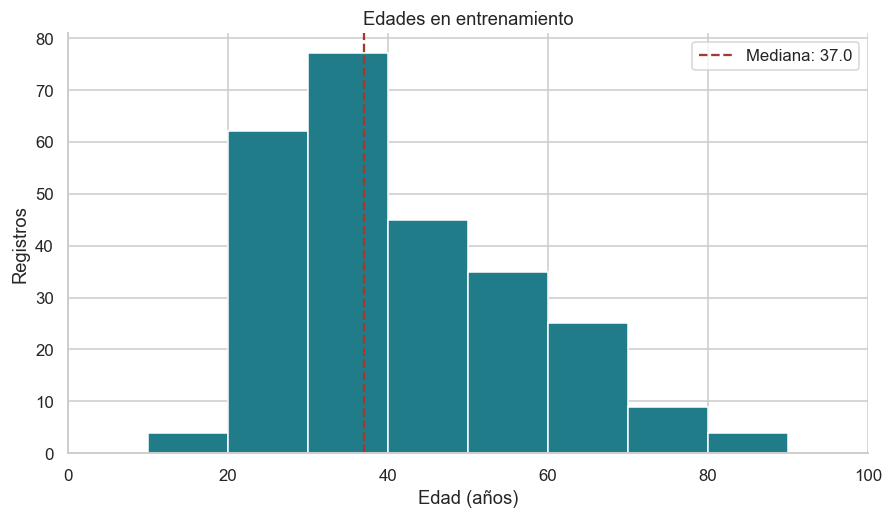

**Interpretación:** las edades abarcan **17–82 años**; la mediana es 37.0 y la media 40.8. El coeficiente de asimetría muestral es 0.75; el histograma permite ver dónde hay soporte de datos, sin asumir normalidad. **Recomendación:** usar un escalamiento robusto para KNN y exigir datos adicionales antes de interpretar predicciones para edades con muy pocos ejemplos.

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.6), layout="constrained")
ax.hist(edad, bins=np.arange(0, 101, 10), color="#217C8A", edgecolor="white")
ax.axvline(edad.median(), color="#A33A32", linestyle="--", label=f"Mediana: {edad.median():.1f}")
ax.set(title="Edades en entrenamiento", xlabel="Edad (años)", ylabel="Registros", xlim=(0, 100))
ax.legend()
guardar_figura(fig, "eda_histograma")
display(Markdown(
    f"**Interpretación:** las edades abarcan **{edad.min():.0f}–{edad.max():.0f} años**; "
    f"la mediana es {edad.median():.1f} y la media {edad.mean():.1f}. "
    f"El coeficiente de asimetría muestral es {edad.skew():.2f}; "
    "el histograma permite ver dónde hay soporte de datos, sin asumir normalidad. "
    "**Recomendación:** usar un escalamiento robusto para KNN y exigir datos adicionales antes de "
    "interpretar predicciones para edades con muy pocos ejemplos."
))

### Dispersión: edad frente al conteo de antecedentes

El color muestra la recurrencia registrada. El desplazamiento vertical aleatorio
(*jitter*, ±0,065) se usa solo para separar puntos superpuestos; los valores
reales del conteo siguen siendo enteros 0, 1 y 2.


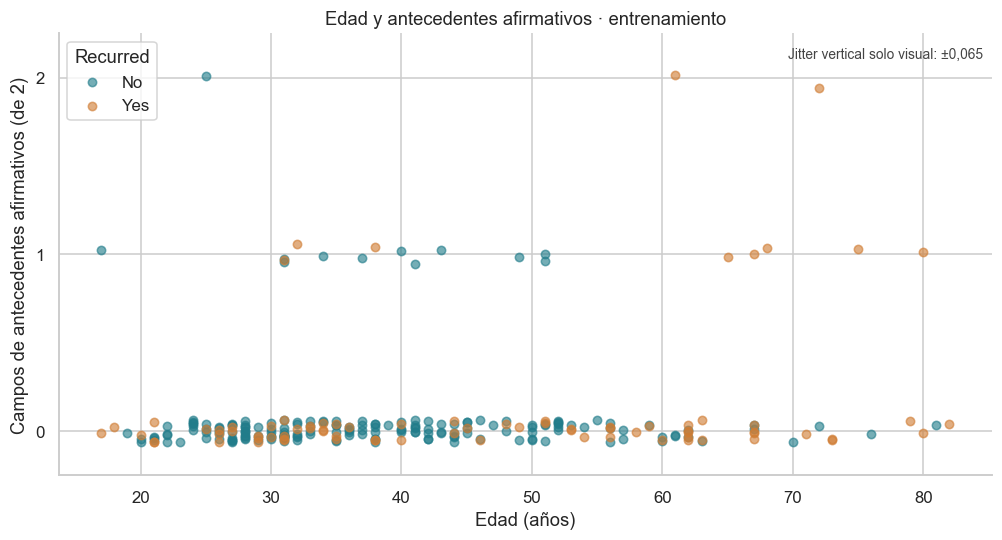

,registros,edad_min,edad_mediana,edad_max,recurrencias
n_antecedentes_afirmativos,,,,,
0,239,17,36.0000,82,69
1,19,17,41.0000,80,8
2,3,25,61.0000,72,2


**Interpretación:** 239 de 261 registros se concentran en cero campos afirmativos. Los grupos con uno y dos aportan solo 19 y 3 casos; sus medianas de edad son 41.0 y 61.0 años. El gráfico describe el soporte y la superposición de edades, no una relación causal ni una escala de riesgo. **Recomendación:** conservar ambos antecedentes por separado en los modelos y ampliar la muestra antes de comparar grupos con pocos casos. El conteo y el jitter no cambian los datos de entrenamiento del modelo.

In [13]:
jitter_rng = np.random.default_rng(SEED)
jitter = jitter_rng.uniform(-0.065, 0.065, len(y_train))
fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
for clase, color in [(0, "#217C8A"), (1, "#D07D34")]:
    mask = y_train.to_numpy() == clase
    ax.scatter(edad.to_numpy()[mask], conteo_antecedentes.to_numpy(dtype=float)[mask] + jitter[mask],
               s=30, alpha=.62, color=color, label="Yes" if clase else "No")
ax.set(title="Edad y antecedentes afirmativos · entrenamiento",
       xlabel="Edad (años)", ylabel="Campos de antecedentes afirmativos (de 2)",
       yticks=[0, 1, 2], ylim=(-.25, 2.25))
ax.legend(title="Recurred", loc="upper left")
ax.text(.99, .97, "Jitter vertical solo visual: ±0,065", transform=ax.transAxes,
        ha="right", va="top", fontsize=9, color="#444444")
guardar_figura(fig, "eda_dispersion")
resumen_conteo = train_eda.groupby(CONTEO_ANTECEDENTES).agg(
    registros=("Age", "size"), edad_min=("Age", "min"), edad_mediana=("Age", "median"),
    edad_max=("Age", "max"), recurrencias=("Recurred", lambda s: (s == "Yes").sum())
)
display(resumen_conteo)
resumen_conteo.to_csv(REPORT_DIR / "clasificacion_antecedentes_por_conteo_train.csv")
display(Markdown(
    f"**Interpretación:** {int(resumen_conteo.loc[0, 'registros'])} de {len(X_train)} "
    "registros se concentran en cero campos afirmativos. "
    f"Los grupos con uno y dos aportan solo {int(resumen_conteo.loc[1, 'registros'])} y "
    f"{int(resumen_conteo.loc[2, 'registros'])} casos; sus medianas de edad son "
    f"{resumen_conteo.loc[1, 'edad_mediana']:.1f} y {resumen_conteo.loc[2, 'edad_mediana']:.1f} años. "
    "El gráfico describe el soporte y la superposición de edades, no una relación causal "
    "ni una escala de riesgo. **Recomendación:** conservar ambos antecedentes por separado "
    "en los modelos y ampliar la muestra antes de comparar grupos con pocos casos. "
    "El conteo y el jitter no cambian los datos de entrenamiento del modelo."
))


### Boxplot: dispersión de edades por clase

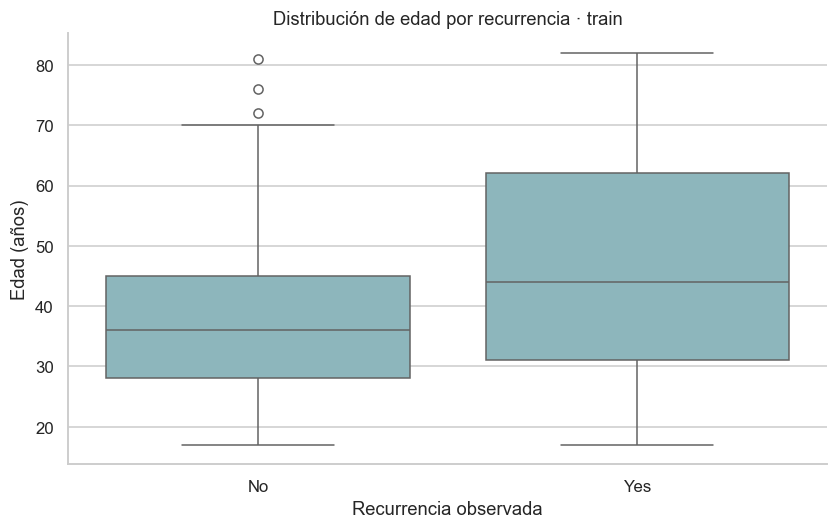

,n,mediana,q1,q3
Recurred,,,,
No,182,36.0000,28.0000,45.0000
Yes,79,44.0000,31.0000,62.0000


**Interpretación:** el 50% central de edades está entre **28.0 y 45.0 años para No**, y entre **31.0 y 62.0 para Yes**. Los puntos fuera de bigotes son extremos dentro de cada clase, distintos del IQR global calculado antes. **Recomendación:** conservar edades plausibles y no interpretar diferencias de cajas como evidencia causal o como una prueba estadística formal.

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.7), layout="constrained")
sns.boxplot(data=train_eda, x="Recurred", y="Age", order=["No", "Yes"],
            color="#85BCC4", ax=ax)
ax.set(title="Distribución de edad por recurrencia · train",
       xlabel="Recurrencia observada", ylabel="Edad (años)")
guardar_figura(fig, "eda_boxplot")
edad_clase = train_eda.groupby("Recurred")["Age"].agg(
    n="size", mediana="median", q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75)
)
display(edad_clase)
display(Markdown(
    f"**Interpretación:** el 50% central de edades está entre "
    f"**{edad_clase.loc['No', 'q1']:.1f} y {edad_clase.loc['No', 'q3']:.1f} años para No**, "
    f"y entre **{edad_clase.loc['Yes', 'q1']:.1f} y {edad_clase.loc['Yes', 'q3']:.1f} para Yes**. "
    "Los puntos fuera de bigotes son extremos dentro de cada clase, distintos del IQR global "
    "calculado antes. **Recomendación:** conservar edades plausibles y no interpretar diferencias "
    "de cajas como evidencia causal o como una prueba estadística formal."
))

### Encoding e imputación por variable (puntos 9–10)

Se utiliza One-Hot para las 14 categorías predictoras: no impone distancias entre
etiquetas. En `Risk`, `T`, `N`, `M` y `Stage` se sacrifica una posible ordenación
clínica para evitar suponer que niveles consecutivos están igualmente separados,
especialmente al usar KNN. No se usa binary encoding porque la cardinalidad es
pequeña, y los bits harían menos directa la interpretación. Se conserva toda
categoría de entrenamiento (`drop=None`). `handle_unknown='ignore'` permite
transformar una etiqueta nueva con ceros en ese bloque; no significa que el
modelo haya aprendido su comportamiento.

`Age` se imputa con mediana y escala con RobustScaler (mediana e IQR). Es relevante
para las distancias de KNN; los árboles no requieren escalamiento, pero se conserva
el mismo preprocesamiento para hacer comparable el experimento. RobustScaler
no elimina outliers ni garantiza distancias óptimas entre edad y One-Hot.

In [15]:
razones_encoding = {
    "Gender": "Nominal: sin orden cuantitativo.",
    "Smoking": "Binaria: One-Hot mantiene el bloque categórico común.",
    "Hx Smoking": "Binaria: no se supone intensidad del antecedente.",
    "Hx Radiothreapy": "Binaria: no representa dosis ni tiempo.",
    "Thyroid Function": "Estados funcionales: no se supone distancia lineal.",
    "Physical Examination": "Hallazgos distintos sin orden de distancia.",
    "Adenopathy": "Estados/localizaciones: no existe distancia numérica natural.",
    "Pathology": "Tipos histológicos nominales, no rangos numéricos.",
    "Focality": "Tipos de focalidad: no se inventa una escala continua.",
    "Risk": "Hay orden clínico, pero no intervalos iguales demostrados.",
    "T": "Categoría TNM con subniveles: evitar distancias arbitrarias.",
    "N": "Categorías de ganglios: no equivalen a un conteo.",
    "M": "Categoría de metástasis: mantener One-Hot común.",
    "Stage": "Estadios ordenados sin intervalos numéricos uniformes.",
}
encoding_audit = pd.DataFrame([
    {"Variable": col, "Categorías train": X_train[col].nunique(),
     "Imputación": "Moda", "Encoding": "One-Hot", "Justificación": razones_encoding[col]}
    for col in categorical_cols
])
display(encoding_audit)
encoding_audit.to_csv(REPORT_DIR / "clasificacion_encoding.csv", index=False)

,Variable,Categorías train,Imputación,Encoding,Justificación
0,Gender,2,Moda,One-Hot,Nominal: sin orden cuantitativo.
1,Smoking,2,Moda,One-Hot,Binaria: One-Hot mantiene el bloque categórico...
2,Hx Smoking,2,Moda,One-Hot,Binaria: no se supone intensidad del antecedente.
3,Hx Radiothreapy,2,Moda,One-Hot,Binaria: no representa dosis ni tiempo.
4,Thyroid Function,5,Moda,One-Hot,Estados funcionales: no se supone distancia li...
5,Physical Examination,5,Moda,One-Hot,Hallazgos distintos sin orden de distancia.
6,Adenopathy,6,Moda,One-Hot,Estados/localizaciones: no existe distancia nu...
7,Pathology,4,Moda,One-Hot,"Tipos histológicos nominales, no rangos numéri..."
8,Focality,2,Moda,One-Hot,Tipos de focalidad: no se inventa una escala c...
9,Risk,3,Moda,One-Hot,"Hay orden clínico, pero no intervalos iguales ..."


## Pipelines y entrenamiento (puntos 12–13, 16–17)

Cada estimador recibe su propio `Pipeline` con un `ColumnTransformer`. `fit`
aprende transformaciones y modelo exclusivamente de `X_train, y_train`; `predict`
sobre validación y test solo aplica las transformaciones aprendidas y predice.
En CV se clonará el pipeline completo dentro de cada fold. Véase la
[guía de prevención de fuga de scikit-learn](https://scikit-learn.org/stable/common_pitfalls.html).

Se conservan las configuraciones iniciales de scikit-learn: KNN con 5 vecinos,
árbol sin límite de profundidad, Random Forest con 100 árboles y Gradient
Boosting con 100 etapas. Las semillas son 42 en estimadores aleatorios. RF usa
`n_jobs=-1` solo para paralelizar, sin cambiar la definición estadística.
No se hace búsqueda de hiperparámetros, SMOTE ni ajuste de umbral; se usa
`predict` de cada estimador. El predictor trivial siempre elige la clase más
frecuente de entrenamiento y no participa en la selección entre los cuatro modelos.

In [16]:
def construir_pipeline(estimador):
    numerico = Pipeline([
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalamiento", RobustScaler()),
    ])
    categorico = Pipeline([
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("encoding", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    preprocess = ColumnTransformer([
        ("num", numerico, numeric_cols),
        ("cat", categorico, categorical_cols),
    ], remainder="drop", sparse_threshold=0)
    return Pipeline([("preprocesamiento", preprocess), ("modelo", estimador)])

estimadores = {
    "KNN": KNeighborsClassifier(),
    "Árbol de decisión": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
}
nombres_obligatorios = list(estimadores)
estimadores["Dummy mayoritario"] = DummyClassifier(strategy="most_frequent", random_state=SEED)
modelos = {name: construir_pipeline(clone(est)) for name, est in estimadores.items()}
parametros = {name: est.get_params(deep=False) for name, est in estimadores.items()}
(REPORT_DIR / "clasificacion_parametros.json").write_text(
    json.dumps(parametros, ensure_ascii=False, indent=2), encoding="utf-8"
)
display(pd.DataFrame([
    {"Modelo": "KNN", "Configuración principal": "5 vecinos; pesos uniformes; distancia Minkowski p=2"},
    {"Modelo": "Árbol de decisión", "Configuración principal": "Gini; max_depth=None; min_samples_leaf=1; seed=42"},
    {"Modelo": "Random Forest", "Configuración principal": "100 árboles; max_features=sqrt; bootstrap=True; seed=42"},
    {"Modelo": "Gradient Boosting", "Configuración principal": "100 etapas; learning_rate=0.1; max_depth=3; seed=42"},
    {"Modelo": "Dummy mayoritario", "Configuración principal": "Clase más frecuente de train"},
]))
display(modelos["KNN"])

,Modelo,Configuración principal
0,KNN,5 vecinos; pesos uniformes; distancia Minkowsk...
1,Árbol de decisión,Gini; max_depth=None; min_samples_leaf=1; seed=42
2,Random Forest,100 árboles; max_features=sqrt; bootstrap=True...
3,Gradient Boosting,100 etapas; learning_rate=0.1; max_depth=3; se...
4,Dummy mayoritario,Clase más frecuente de train


,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Métricas y costos de error (punto 19)

`Accuracy = (TP+TN)/N` mide aciertos totales. `Precision = TP/(TP+FP)` expresa qué
fracción de las predicciones de recurrencia es correcta. `Recall = TP/(TP+FN)`
expresa qué fracción de las recurrencias observadas se identifica. F1 es la media
armónica entre Precision y Recall; penaliza que una sea muy baja. Todas se calculan
con `Yes=1` como positivo y `zero_division=0` cuando no se predice ningún positivo.

Un falso negativo es una recurrencia observada predicha como `No`; un falso
positivo es una no recurrencia observada predicha como `Yes`. Para este ejercicio
se prioriza Recall porque omitir recurrencias es el error que se busca reducir,
sin ignorar falsas alertas ni convertir la preferencia en una regla clínica.
Los costos reales necesitarían un protocolo, un momento de predicción y validación
externa. Las matrices siempre usan filas = clase real, columnas = predicción,
orden `[No, Yes]`.

In [17]:
metric_names = ["Accuracy", "Precision", "Recall", "F1"]

def medir(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

filas_metricas = []
tiempos = {}
predicciones = {}
matrices = {}
for name, pipeline in modelos.items():
    t0 = perf_counter()
    pipeline.fit(X_train, y_train)
    tiempos[name] = {"fit_s": perf_counter() - t0}
    for conjunto, X_part, y_part in [("train", X_train, y_train), ("validacion", X_val, y_val)]:
        t0 = perf_counter()
        pred = pipeline.predict(X_part)
        tiempos[name][f"predict_{conjunto}_s"] = perf_counter() - t0
        predicciones[(name, conjunto)] = pred
        matrices[(name, conjunto)] = confusion_matrix(y_part, pred, labels=[0, 1])
        filas_metricas.append({"Modelo": name, "Conjunto": conjunto, **medir(y_part, pred)})
metricas_tv = pd.DataFrame(filas_metricas)
tabla_tv = metricas_tv.pivot(index="Modelo", columns="Conjunto", values=metric_names)
tabla_tv = tabla_tv.reindex(list(modelos))
display(tabla_tv)
display(pd.DataFrame(tiempos).T)
metricas_tv.to_csv(REPORT_DIR / "clasificacion_metricas_train_validacion.csv", index=False)
tabla_tv.to_csv(REPORT_DIR / "clasificacion_comparativa_train_validacion.csv")

Accuracy            Precision            Recall             \
Conjunto             train validacion     train validacion  train validacion   
Modelo                                                                         
KNN                 0.9080     0.8654    0.9104     0.7692 0.7722     0.7143   
Árbol de decisión   0.9962     0.8269    1.0000     0.6923 0.9873     0.6429   
Random Forest       0.9962     0.9038    1.0000     0.8462 0.9873     0.7857   
Gradient Boosting   0.9885     0.9038    0.9750     0.8462 0.9873     0.7857   
Dummy mayoritario   0.6973     0.7308    0.0000     0.0000 0.0000     0.0000   

                      F1             
Conjunto           train validacion  
Modelo                               
KNN               0.8356     0.7407  
Árbol de decisión 0.9936     0.6667  
Random Forest     0.9936     0.8148  
Gradient Boosting 0.9811     0.8148  
Dummy mayoritario 0.0000     0.0000

,fit_s,predict_train_s,predict_validacion_s
KNN,0.0054,0.0510,0.0050
Árbol de decisión,0.0049,0.0020,0.0022
Random Forest,0.0766,0.0152,0.0147
Gradient Boosting,0.0508,0.0023,0.0020
Dummy mayoritario,0.0042,0.0025,0.0019


### Las ocho matrices de train y validación (puntos 19–20)

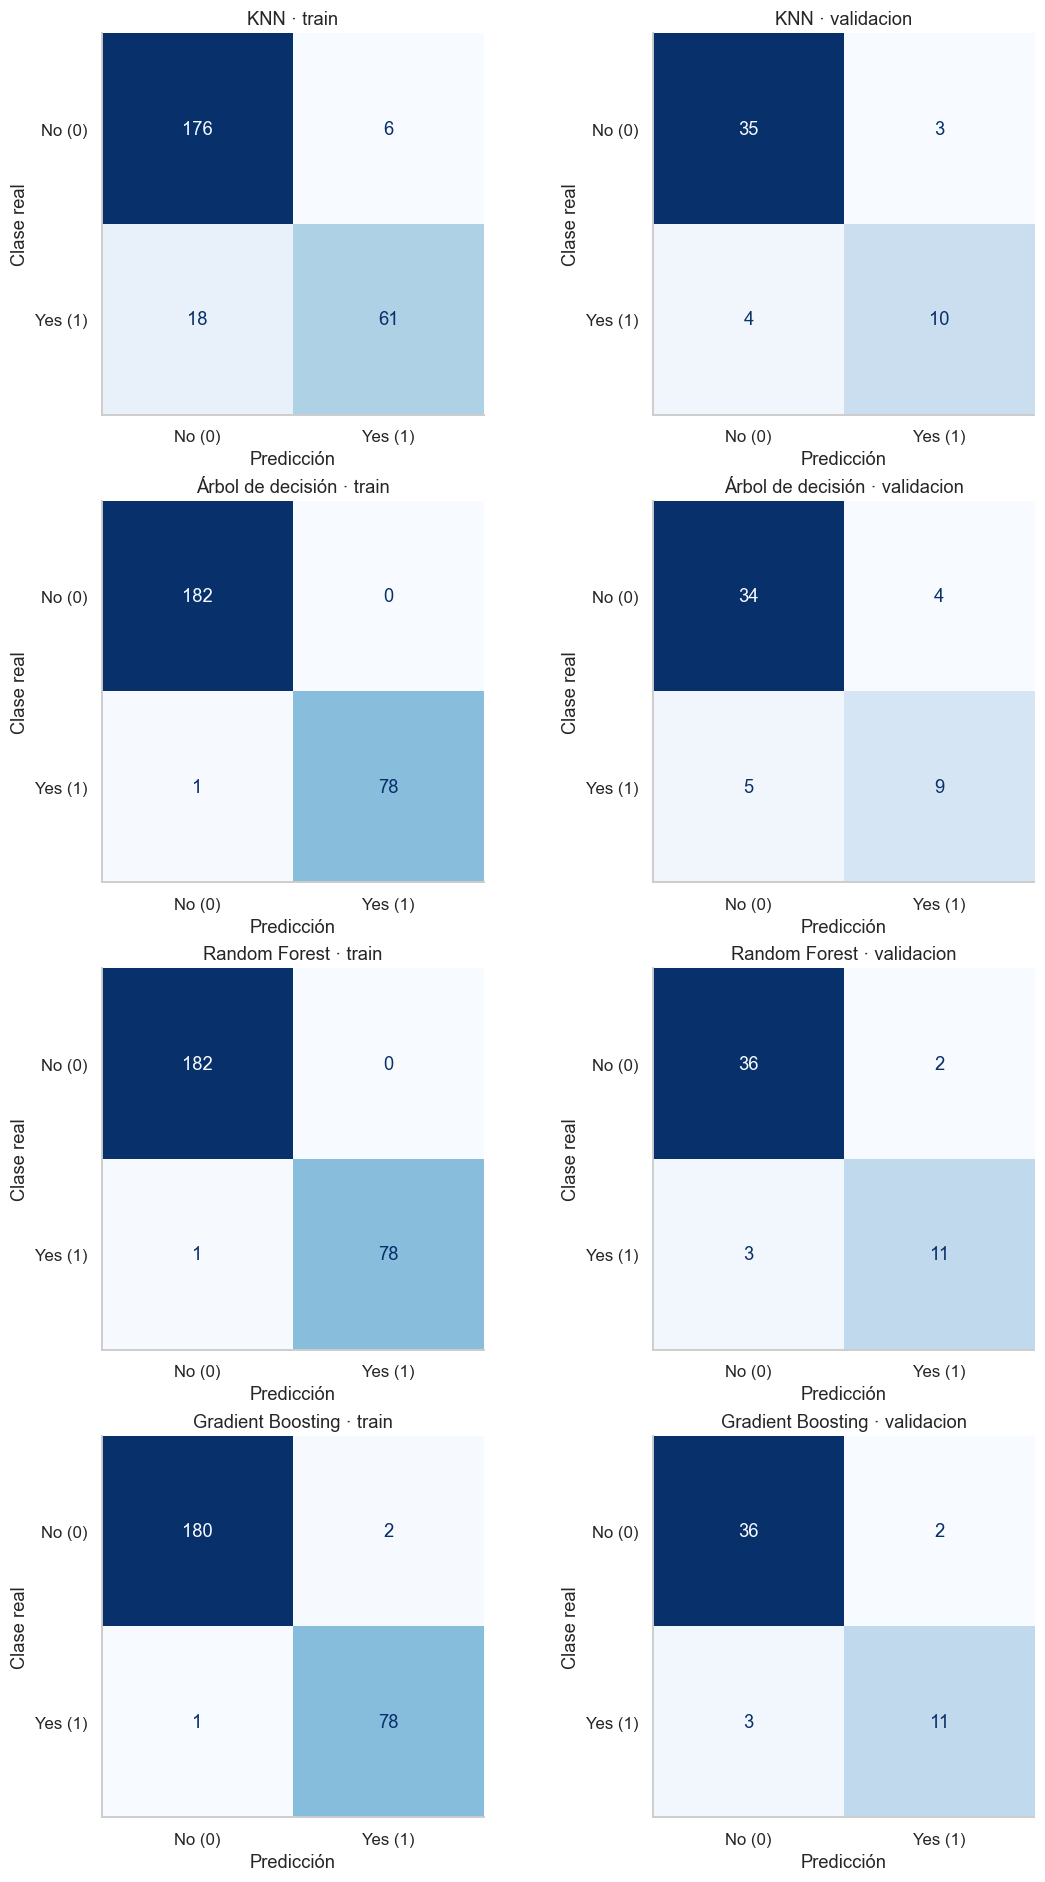

**KNN:** F1 train=0.836, validación=0.741 (brecha train−val=+0.095); la caída es una señal de posible sobreajuste; un único split no lo demuestra por sí solo. Recall pasa de 0.772 a 0.714. En validación identifica 10 recurrencias, omite **4** y genera **3** falsas alertas (35 negativos correctos). Precision=0.769 y Accuracy=0.865 completan el balance.

**Árbol de decisión:** F1 train=0.994, validación=0.667 (brecha train−val=+0.327); la caída es una señal de posible sobreajuste; un único split no lo demuestra por sí solo. Recall pasa de 0.987 a 0.643. En validación identifica 9 recurrencias, omite **5** y genera **4** falsas alertas (34 negativos correctos). Precision=0.692 y Accuracy=0.827 completan el balance.

**Random Forest:** F1 train=0.994, validación=0.815 (brecha train−val=+0.179); la caída es una señal de posible sobreajuste; un único split no lo demuestra por sí solo. Recall pasa de 0.987 a 0.786. En validación identifica 11 recurrencias, omite **3** y genera **2** falsas alertas (36 negativos correctos). Precision=0.846 y Accuracy=0.904 completan el balance.

**Gradient Boosting:** F1 train=0.981, validación=0.815 (brecha train−val=+0.166); la caída es una señal de posible sobreajuste; un único split no lo demuestra por sí solo. Recall pasa de 0.987 a 0.786. En validación identifica 11 recurrencias, omite **3** y genera **2** falsas alertas (36 negativos correctos). Precision=0.846 y Accuracy=0.904 completan el balance.

**Referencia de subajuste:** Dummy logra Accuracy=0.731 en validación, pero Recall=0.000 y F1=0.000. Su baja capacidad no captura la clase positiva. Para los modelos reales, un desempeño bajo tanto en train como en validación y próximo a esta referencia sugeriría subajuste; una diferencia train/val aislada no basta para diagnosticarlo.

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(10, 17), layout="constrained")
for row, name in enumerate(nombres_obligatorios):
    for col, conjunto in enumerate(["train", "validacion"]):
        disp = ConfusionMatrixDisplay(matrices[(name, conjunto)], display_labels=["No (0)", "Yes (1)"])
        disp.plot(ax=axes[row, col], cmap="Blues", colorbar=False, values_format="d")
        axes[row, col].set(title=f"{name} · {conjunto}", xlabel="Predicción", ylabel="Clase real")
        axes[row, col].grid(False)
guardar_figura(fig, "matrices_train_validacion")

for name in nombres_obligatorios:
    train_row = metricas_tv.query("Modelo == @name and Conjunto == 'train'").iloc[0]
    val_row = metricas_tv.query("Modelo == @name and Conjunto == 'validacion'").iloc[0]
    tn, fp, fn, tp = matrices[(name, "validacion")].ravel()
    gap = train_row["F1"] - val_row["F1"]
    if gap > 0:
        comentario_gap = "la caída es una señal de posible sobreajuste; un único split no lo demuestra por sí solo"
    else:
        comentario_gap = "no hay caída de F1 en este split; esto no demuestra ausencia de sobreajuste"
    display(Markdown(
        f"**{name}:** F1 train={train_row['F1']:.3f}, validación={val_row['F1']:.3f} "
        f"(brecha train−val={gap:+.3f}); {comentario_gap}. "
        f"Recall pasa de {train_row['Recall']:.3f} a {val_row['Recall']:.3f}. "
        f"En validación identifica {tp} recurrencias, omite **{fn}** y genera **{fp}** falsas alertas "
        f"({tn} negativos correctos). Precision={val_row['Precision']:.3f} y "
        f"Accuracy={val_row['Accuracy']:.3f} completan el balance."
    ))
dummy_train = metricas_tv.query("Modelo == 'Dummy mayoritario' and Conjunto == 'train'").iloc[0]
dummy_val = metricas_tv.query("Modelo == 'Dummy mayoritario' and Conjunto == 'validacion'").iloc[0]
display(Markdown(
    f"**Referencia de subajuste:** Dummy logra Accuracy={dummy_val['Accuracy']:.3f} en validación, "
    f"pero Recall={dummy_val['Recall']:.3f} y F1={dummy_val['F1']:.3f}. "
    "Su baja capacidad no captura la clase positiva. Para los modelos reales, un desempeño "
    "bajo tanto en train como en validación y próximo a esta referencia sugeriría subajuste; "
    "una diferencia train/val aislada no basta para diagnosticarlo."
))

### Comprobación explícita del preprocesamiento sin fuga (punto 13)

In [19]:
for name, pipeline in modelos.items():
    prep = pipeline.named_steps["preprocesamiento"]
    num_pipe = prep.named_transformers_["num"]
    cat_pipe = prep.named_transformers_["cat"]
    np.testing.assert_allclose(num_pipe.named_steps["imputacion"].statistics_, X_train[numeric_cols].median())
    train_num_imputed = num_pipe.named_steps["imputacion"].transform(X_train[numeric_cols])
    np.testing.assert_allclose(num_pipe.named_steps["escalamiento"].center_,
                               np.median(train_num_imputed, axis=0))
    np.testing.assert_array_equal(cat_pipe.named_steps["imputacion"].statistics_,
                                  X_train[categorical_cols].mode().iloc[0].to_numpy())
    for col, learned in zip(categorical_cols, cat_pipe.named_steps["encoding"].categories_):
        assert set(learned) == set(X_train[col].dropna().unique()), (name, col)
    assert np.isfinite(prep.transform(X_train)).all()
    assert np.isfinite(prep.transform(X_val)).all()
print("Verificado en los cinco pipelines: mediana, moda y categorías proceden solo de train.")
display(Markdown(
    "La única llamada de entrenamiento fue `pipeline.fit(X_train, y_train)`. "
    "Al predecir validación se ejecutaron `transform` y `predict`, sin `fit`. "
    "Las aserciones contrastan los parámetros aprendidos con train; además, las categorías "
    "de One-Hot coinciden exclusivamente con las observadas allí. El IQR de EDA se calculó "
    "también sobre train y no se usó para retirar filas. Test aún no ha recibido predicciones."
))

Verificado en los cinco pipelines: mediana, moda y categorías proceden solo de train.


La única llamada de entrenamiento fue `pipeline.fit(X_train, y_train)`. Al predecir validación se ejecutaron `transform` y `predict`, sin `fit`. Las aserciones contrastan los parámetros aprendidos con train; además, las categorías de One-Hot coinciden exclusivamente con las observadas allí. El IQR de EDA se calculó también sobre train y no se usó para retirar filas. Test aún no ha recibido predicciones.

## Selección en validación y congelación (punto 21)

Regla fijada antes de abrir test: maximizar **Recall de recurrencia**, luego F1,
luego Precision. Si las tres coinciden, preferir menor brecha absoluta de F1
train/validación; si continúa el empate, priorizar interpretabilidad en el orden
árbol, KNN, Gradient Boosting, Random Forest. Los tiempos medidos se discuten,
pero no desempatan porque dependen de la máquina. Esta regla elige entre los
cuatro modelos requeridos; Dummy solo aporta contexto.

KNN depende de distancias y escala y requiere conservar ejemplos. Un árbol
permite seguir reglas, pero sin poda puede memorizar. Random Forest promedia
árboles y suele reducir la variación de un árbol individual; pierde simplicidad.
Gradient Boosting agrega árboles secuencialmente para corregir errores y tiene
más sensibilidad a su capacidad y tasa de aprendizaje. Son mecanismos, no
garantías de cuál debe ganar en estos datos.

In [20]:
prioridad_interpretabilidad = {"Árbol de decisión": 0, "KNN": 1, "Gradient Boosting": 2, "Random Forest": 3}
ranking_val = metricas_tv[
    (metricas_tv["Conjunto"] == "validacion") & metricas_tv["Modelo"].isin(nombres_obligatorios)
].copy().set_index("Modelo")
train_por_modelo = metricas_tv[metricas_tv["Conjunto"] == "train"].set_index("Modelo")
ranking_val["Brecha absoluta F1"] = (train_por_modelo["F1"] - ranking_val["F1"]).abs()
ranking_val["Prioridad interpretabilidad"] = ranking_val.index.map(prioridad_interpretabilidad)
ranking_val["fit_s"] = ranking_val.index.map(lambda name: tiempos[name]["fit_s"])
ranking_val = ranking_val.sort_values(
    ["Recall", "F1", "Precision", "Brecha absoluta F1", "Prioridad interpretabilidad"],
    ascending=[False, False, False, True, True], kind="stable",
)
ganador = ranking_val.index[0]
seleccion_congelada = {
    "ganador": ganador,
    "criterio": "Recall val descendente; F1; Precision; brecha absoluta F1 ascendente; interpretabilidad",
    "semilla": SEED,
    "metricas_validacion": {k: float(ranking_val.loc[ganador, k]) for k in metric_names},
    "parametros": parametros[ganador],
    "test_usado_para_seleccionar": False,
}
(REPORT_DIR / "clasificacion_seleccion.json").write_text(
    json.dumps(seleccion_congelada, ensure_ascii=False, indent=2), encoding="utf-8"
)
display(ranking_val)
ganador_val = ranking_val.loc[ganador]
empatados_metricas = [name for name in ranking_val.index if all(
    np.isclose(ranking_val.loc[name, met], ganador_val[met], rtol=0, atol=1e-12)
    for met in ["Recall", "F1", "Precision"]
)]
if len(empatados_metricas) > 1:
    detalle_brechas = "; ".join(
        f"{name}: {ranking_val.loc[name, 'Brecha absoluta F1']:.4f}"
        for name in empatados_metricas
    )
    display(Markdown(
        f"**Desempate observado:** {', '.join(empatados_metricas)} empatan en las tres métricas "
        f"prioritarias de validación. Las brechas absolutas de F1 son **{detalle_brechas}**. "
        "Se aplica la regla previamente declarada para preferir la menor brecha; esto es un "
        "criterio operativo de estabilidad en el split, no una prueba estadística de superioridad."
    ))
display(Markdown(
    f"Se selecciona **{ganador}** con Recall={ganador_val['Recall']:.3f}, "
    f"F1={ganador_val['F1']:.3f} y Precision={ganador_val['Precision']:.3f} en validación. "
    f"La brecha absoluta de F1 es {ganador_val['Brecha absoluta F1']:.3f}; "
    f"su ajuste tardó {tiempos[ganador]['fit_s']:.3f} s en esta ejecución. "
    f"Los tiempos de los cuatro modelos estuvieron entre "
    f"{min(tiempos[n]['fit_s'] for n in nombres_obligatorios):.3f} y "
    f"{max(tiempos[n]['fit_s'] for n in nombres_obligatorios):.3f} s. "
    "La tabla permite comprobar qué criterio decidió frente a los demás candidatos. "
    "Su mayor prioridad es identificar recurrencias; Precision refleja las falsas alertas "
    "asociadas a esa elección. **El ganador y los modelos quedan congelados antes de test**; "
    "no se reentrenan con train+validación para esta comparación."
))

,Conjunto,Accuracy,Precision,Recall,F1,Brecha absoluta F1,Prioridad interpretabilidad,fit_s
Modelo,,,,,,,,
Gradient Boosting,validacion,0.9038,0.8462,0.7857,0.8148,0.1663,2,0.0508
Random Forest,validacion,0.9038,0.8462,0.7857,0.8148,0.1788,3,0.0766
KNN,validacion,0.8654,0.7692,0.7143,0.7407,0.0949,1,0.0054
Árbol de decisión,validacion,0.8269,0.6923,0.6429,0.6667,0.3270,0,0.0049


**Desempate observado:** Gradient Boosting, Random Forest empatan en las tres métricas prioritarias de validación. Las brechas absolutas de F1 son **Gradient Boosting: 0.1663; Random Forest: 0.1788**. Se aplica la regla previamente declarada para preferir la menor brecha; esto es un criterio operativo de estabilidad en el split, no una prueba estadística de superioridad.

Se selecciona **Gradient Boosting** con Recall=0.786, F1=0.815 y Precision=0.846 en validación. La brecha absoluta de F1 es 0.166; su ajuste tardó 0.051 s en esta ejecución. Los tiempos de los cuatro modelos estuvieron entre 0.005 y 0.077 s. La tabla permite comprobar qué criterio decidió frente a los demás candidatos. Su mayor prioridad es identificar recurrencias; Precision refleja las falsas alertas asociadas a esa elección. **El ganador y los modelos quedan congelados antes de test**; no se reentrenan con train+validación para esta comparación.

## Evaluación final de todos los clasificadores (puntos 22–23)

Solo ahora se generan predicciones de test. Se evalúan los cuatro modelos
obligatorios y la referencia con los mismos pipelines entrenados antes.
El ranking de test se ordena por Recall, F1 y Precision; los empates reciben
el mismo rango. Ver otro modelo arriba no cambia la selección ya congelada.

In [21]:
assert seleccion_congelada["ganador"] == ganador
filas_test = []
for name, pipeline in modelos.items():
    t0 = perf_counter()
    pred = pipeline.predict(X_test)
    tiempos[name]["predict_test_s"] = perf_counter() - t0
    predicciones[(name, "test")] = pred
    matrices[(name, "test")] = confusion_matrix(y_test, pred, labels=[0, 1])
    filas_test.append({"Modelo": name, "Conjunto": "test", **medir(y_test, pred)})
metricas_test = pd.DataFrame(filas_test).set_index("Modelo")
display(metricas_test)
metricas_test.to_csv(REPORT_DIR / "clasificacion_metricas_test.csv")
pd.DataFrame(tiempos).T.to_csv(REPORT_DIR / "clasificacion_tiempos.csv", index_label="Modelo")

def rangos_metricas(tabla):
    claves = {nombre: tuple(float(tabla.loc[nombre, met]) for met in ["Recall", "F1", "Precision"])
              for nombre in nombres_obligatorios}
    orden = sorted(set(claves.values()), reverse=True)
    return pd.Series({nombre: orden.index(clave) + 1 for nombre, clave in claves.items()})

comparacion_test = pd.DataFrame({
    "Rango validación": rangos_metricas(ranking_val),
    "Rango test": rangos_metricas(metricas_test),
    "Recall validación": ranking_val["Recall"], "Recall test": metricas_test.loc[nombres_obligatorios, "Recall"],
    "F1 validación": ranking_val["F1"], "F1 test": metricas_test.loc[nombres_obligatorios, "F1"],
})
comparacion_test["Δ Recall test−val"] = comparacion_test["Recall test"] - comparacion_test["Recall validación"]
comparacion_test["Δ F1 test−val"] = comparacion_test["F1 test"] - comparacion_test["F1 validación"]
display(comparacion_test.sort_values("Rango validación"))
comparacion_test.to_csv(REPORT_DIR / "clasificacion_rankings.csv")
ganador_test = metricas_test.loc[ganador]
tn, fp, fn, tp = matrices[(ganador, "test")].ravel()
ranking_igual = bool((comparacion_test["Rango validación"] == comparacion_test["Rango test"]).all())
display(Markdown(
    f"Los rangos **{'se mantienen' if ranking_igual else 'cambian'}** entre validación y test. "
    f"El ganador congelado, **{ganador}**, obtiene Recall={ganador_test['Recall']:.3f}, "
    f"Precision={ganador_test['Precision']:.3f}, F1={ganador_test['F1']:.3f} y "
    f"Accuracy={ganador_test['Accuracy']:.3f}. Identifica **{tp} de {tp + fn} recurrencias**, "
    f"omite **{fn}** y produce **{fp} falsas alertas**. Su Recall cambia "
    f"{ganador_test['Recall'] - ganador_val['Recall']:+.3f} y su F1 "
    f"{ganador_test['F1'] - ganador_val['F1']:+.3f} respecto a validación. "
    f"En test, un solo falso negativo adicional cambia Recall en {1 / int(y_test.sum()):.3f}; "
    "esto hace sensibles las métricas en una muestra pequeña. Diferencias grandes también "
    "pueden reflejar composición de perfiles, variación muestral o sobreajuste. "
    "No se ajusta el modelo después de observarlas; se contrasta la estabilidad con CV y "
    "se requeriría una cohorte externa para separar esas explicaciones."
))

,Conjunto,Accuracy,Precision,Recall,F1
Modelo,,,,,
KNN,test,0.8627,0.8333,0.6667,0.7407
Árbol de decisión,test,0.8431,0.7333,0.7333,0.7333
Random Forest,test,0.9216,0.8667,0.8667,0.8667
Gradient Boosting,test,0.9216,0.9231,0.8000,0.8571
Dummy mayoritario,test,0.7059,0.0000,0.0000,0.0000


,Rango validación,Rango test,Recall validación,Recall test,F1 validación,F1 test,Δ Recall test−val,Δ F1 test−val
Gradient Boosting,1,2,0.7857,0.8000,0.8148,0.8571,0.0143,0.0423
Random Forest,1,1,0.7857,0.8667,0.8148,0.8667,0.0810,0.0519
KNN,2,4,0.7143,0.6667,0.7407,0.7407,-0.0476,0.0000
Árbol de decisión,3,3,0.6429,0.7333,0.6667,0.7333,0.0905,0.0667


Los rangos **cambian** entre validación y test. El ganador congelado, **Gradient Boosting**, obtiene Recall=0.800, Precision=0.923, F1=0.857 y Accuracy=0.922. Identifica **12 de 15 recurrencias**, omite **3** y produce **1 falsas alertas**. Su Recall cambia +0.014 y su F1 +0.042 respecto a validación. En test, un solo falso negativo adicional cambia Recall en 0.067; esto hace sensibles las métricas en una muestra pequeña. Diferencias grandes también pueden reflejar composición de perfiles, variación muestral o sobreajuste. No se ajusta el modelo después de observarlas; se contrasta la estabilidad con CV y se requeriría una cohorte externa para separar esas explicaciones.

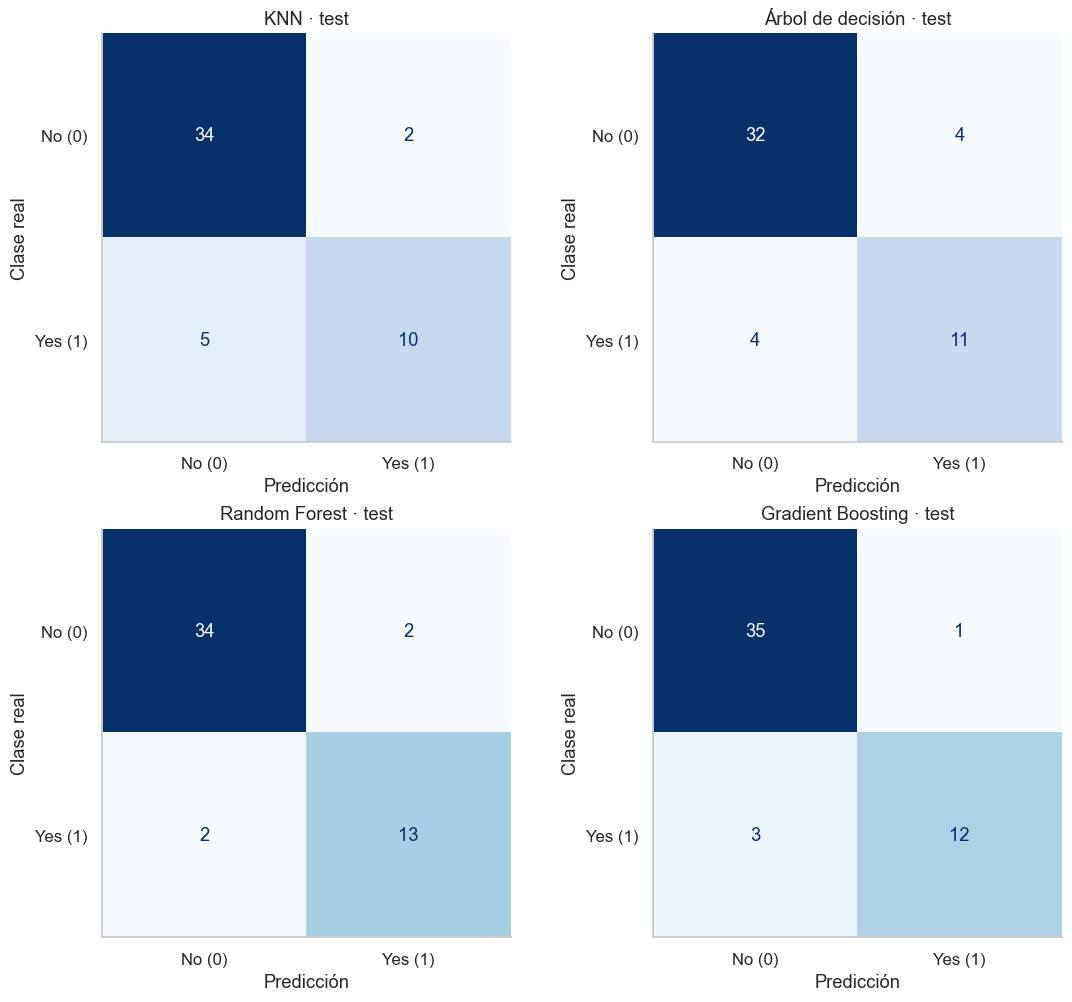

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9), layout="constrained")
for ax, name in zip(axes.flat, nombres_obligatorios):
    ConfusionMatrixDisplay(matrices[(name, "test")], display_labels=["No (0)", "Yes (1)"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d"
    )
    ax.set(title=f"{name} · test", xlabel="Predicción", ylabel="Clase real")
    ax.grid(False)
guardar_figura(fig, "matrices_test")

## Validación cruzada del ganador (puntos 24, 26–27)

K-Fold divide los datos disponibles en K bloques: entrena con K−1 y evalúa con el
restante, repitiendo hasta que cada bloque haya sido evaluado. Promediar resultados
reduce la dependencia de una sola partición y su dispersión ayuda a ver
sensibilidad a los datos. Los entrenamientos se solapan, por lo que la desviación
entre folds **no es un intervalo de confianza** ni garantiza generalización.

Aquí se usa **StratifiedGroupKFold con 5 folds** exclusivamente dentro de train.
Los perfiles permanecen separados y se intenta conservar el balance de clases.
En cada fold se clona el pipeline completo: ni siquiera la mediana, la moda o
One-Hot pueden aprender del bloque que se evalúa. No se usa test ni se cambia el
ganador a partir de CV; la selección se hizo en validación y esta comprobación es
diagnóstica, no una estimación independiente del proceso entero de selección.
Fuente metodológica: [scikit-learn, validación cruzada](https://scikit-learn.org/stable/modules/cross_validation.html).

In [23]:
cv_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
auditoria_folds = []
for fold, (fit_idx, eval_idx) in enumerate(cv_splitter.split(X_train, y_train, groups_train), start=1):
    assert set(groups_train.iloc[fit_idx]).isdisjoint(groups_train.iloc[eval_idx])
    assert y_train.iloc[fit_idx].nunique() == 2 and y_train.iloc[eval_idx].nunique() == 2
    auditoria_folds.append({"Fold": fold, "Filas ajuste": len(fit_idx), "Filas evaluación": len(eval_idx),
                            "Yes ajuste": int(y_train.iloc[fit_idx].sum()),
                            "Yes evaluación": int(y_train.iloc[eval_idx].sum())})
display(pd.DataFrame(auditoria_folds))
scoring = {
    "Accuracy": make_scorer(accuracy_score),
    "Precision": make_scorer(precision_score, pos_label=1, zero_division=0),
    "Recall": make_scorer(recall_score, pos_label=1, zero_division=0),
    "F1": make_scorer(f1_score, pos_label=1, zero_division=0),
}
cv_result = cross_validate(
    clone(modelos[ganador]), X_train, y_train, groups=groups_train,
    cv=cv_splitter, scoring=scoring, return_train_score=True, n_jobs=1, error_score="raise",
)
cv_folds = pd.DataFrame({
    "Fold": np.arange(1, 6),
    **{met: cv_result[f"test_{met}"] for met in metric_names},
    **{f"Train {met}": cv_result[f"train_{met}"] for met in metric_names},
    "fit_s": cv_result["fit_time"], "score_s": cv_result["score_time"],
})
cv_resumen = pd.DataFrame({
    "Media CV": cv_folds[metric_names].mean(),
    "Desviación CV (ddof=1)": cv_folds[metric_names].std(ddof=1),
    "Mínimo fold": cv_folds[metric_names].min(), "Máximo fold": cv_folds[metric_names].max(),
    "Validación original": ganador_val[metric_names].astype(float),
})
cv_resumen["Δ media CV−validación"] = cv_resumen["Media CV"] - cv_resumen["Validación original"]
display(cv_folds)
display(cv_resumen)
cv_folds.to_csv(REPORT_DIR / "clasificacion_cv_folds.csv", index=False)
cv_resumen.to_csv(REPORT_DIR / "clasificacion_cv_resumen.csv", index_label="Métrica")
pd.DataFrame(auditoria_folds).to_csv(REPORT_DIR / "clasificacion_cv_particiones.csv", index=False)

delta_cv = cv_resumen.loc["Recall", "Δ media CV−validación"]
direccion_cv = "menor" if delta_cv < 0 else "mayor" if delta_cv > 0 else "igual"
display(Markdown(
    f"El Recall medio de CV es **{cv_resumen.loc['Recall', 'Media CV']:.3f} ± "
    f"{cv_resumen.loc['Recall', 'Desviación CV (ddof=1)']:.3f}** (desviación entre 5 folds), "
    f"{direccion_cv} que {ganador_val['Recall']:.3f} de validación "
    f"(diferencia {delta_cv:+.3f}). Los folds van de "
    f"{cv_folds['Recall'].min():.3f} a {cv_folds['Recall'].max():.3f} en Recall y de "
    f"{cv_folds['F1'].min():.3f} a {cv_folds['F1'].max():.3f} en F1. "
    "Esta variación cuantifica la sensibilidad al reparto de perfiles: cuanto más amplio el "
    "rango, menos convincente resulta resumir el modelo con un único número. Cada ajuste de CV "
    "usa cerca del 80% de train, menos registros que el modelo de la validación original; "
    "el cambio de score no representa una mejora o deterioro de un modelo reentrenado. "
    "También cambian los casos evaluados y el balance efectivo."
))

,Fold,Filas ajuste,Filas evaluación,Yes ajuste,Yes evaluación
0,1,208,53,62,17
1,2,211,50,64,15
2,3,207,54,64,15
3,4,209,52,63,16
4,5,209,52,63,16


,Fold,Accuracy,Precision,Recall,F1,Train Accuracy,Train Precision,Train Recall,Train F1,fit_s,score_s
0,1,0.8491,0.7368,0.8235,0.7778,0.9952,1.0000,0.9839,0.9919,0.0484,0.0057
1,2,0.8400,0.7692,0.6667,0.7143,0.9953,1.0000,0.9844,0.9921,0.0457,0.0061
2,3,0.9074,0.8125,0.8667,0.8387,0.9952,0.9846,1.0000,0.9922,0.0467,0.0058
3,4,0.8269,0.6842,0.8125,0.7429,0.9952,1.0000,0.9841,0.9920,0.0485,0.0051
4,5,0.8654,0.8462,0.6875,0.7586,0.9952,1.0000,0.9841,0.9920,0.0479,0.0046


,Media CV,Desviación CV (ddof=1),Mínimo fold,Máximo fold,Validación original,Δ media CV−validación
Accuracy,0.8578,0.0311,0.8269,0.9074,0.9038,-0.0461
Precision,0.7698,0.0634,0.6842,0.8462,0.8462,-0.0764
Recall,0.7714,0.0887,0.6667,0.8667,0.7857,-0.0143
F1,0.7665,0.0466,0.7143,0.8387,0.8148,-0.0484


El Recall medio de CV es **0.771 ± 0.089** (desviación entre 5 folds), menor que 0.786 de validación (diferencia -0.014). Los folds van de 0.667 a 0.867 en Recall y de 0.714 a 0.839 en F1. Esta variación cuantifica la sensibilidad al reparto de perfiles: cuanto más amplio el rango, menos convincente resulta resumir el modelo con un único número. Cada ajuste de CV usa cerca del 80% de train, menos registros que el modelo de la validación original; el cambio de score no representa una mejora o deterioro de un modelo reentrenado. También cambian los casos evaluados y el balance efectivo.

## Síntesis visual en un subplot 2×2 (punto 28)

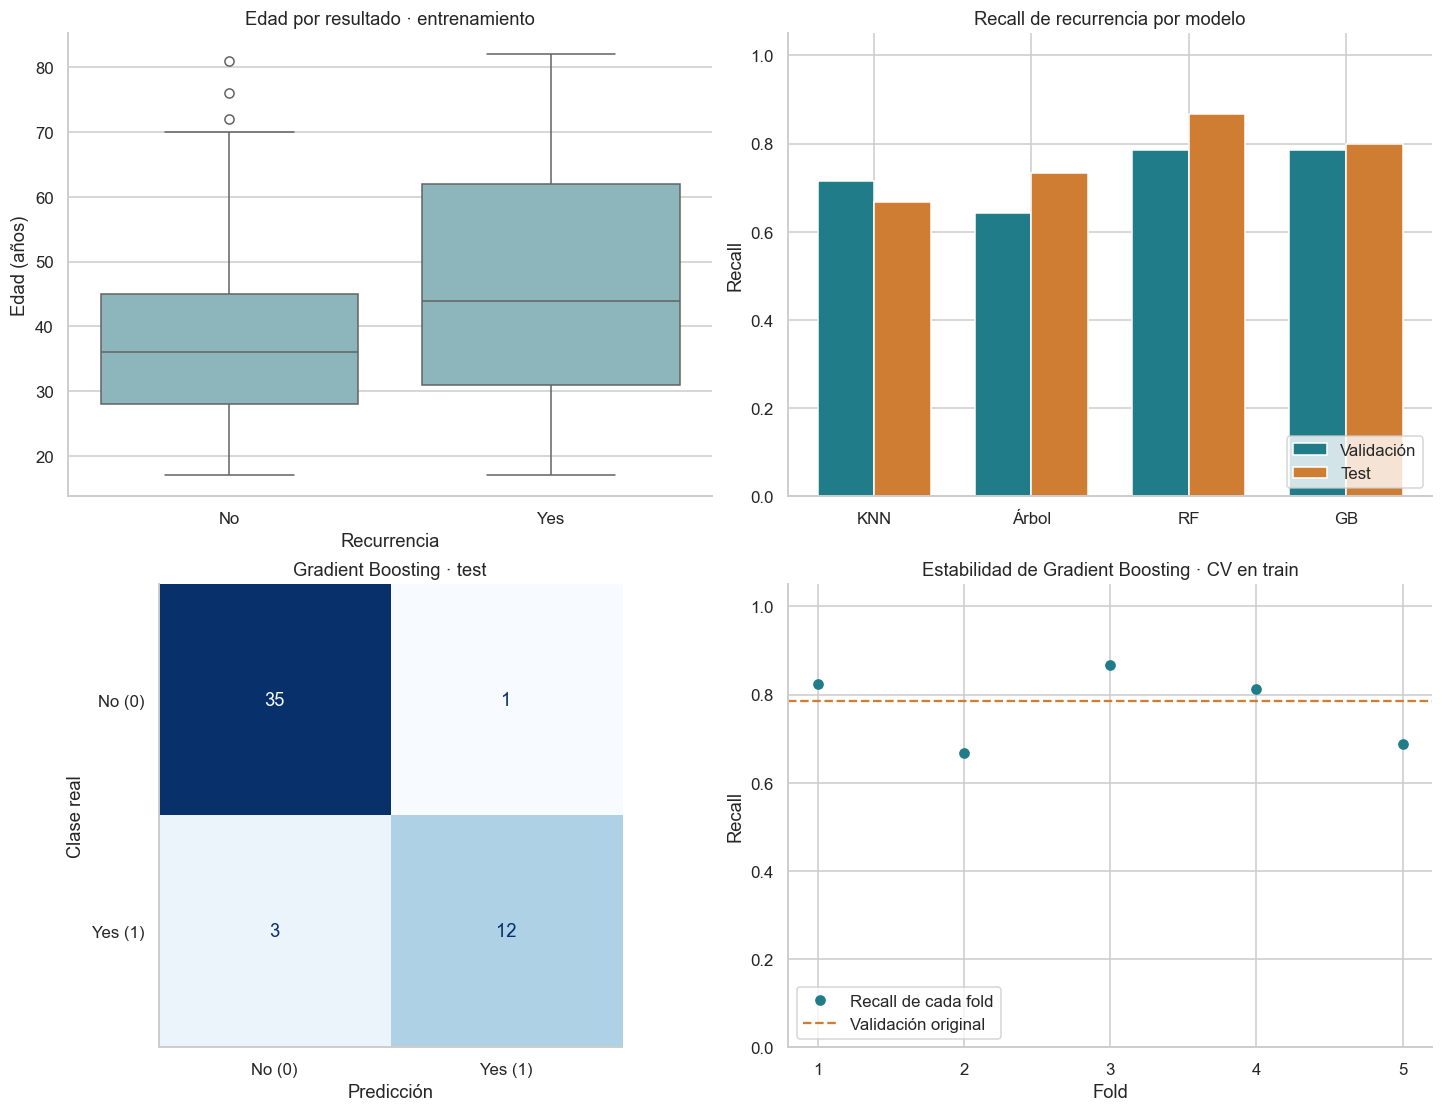

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), layout="constrained")
sns.boxplot(data=train_eda, x="Recurred", y="Age", order=["No", "Yes"], color="#85BCC4", ax=axes[0, 0])
axes[0, 0].set(title="Edad por resultado · entrenamiento", xlabel="Recurrencia", ylabel="Edad (años)")

short_labels = ["KNN", "Árbol", "RF", "GB"]
x = np.arange(len(nombres_obligatorios))
width = .36
axes[0, 1].bar(x - width/2, ranking_val.loc[nombres_obligatorios, "Recall"], width, label="Validación", color="#217C8A")
axes[0, 1].bar(x + width/2, metricas_test.loc[nombres_obligatorios, "Recall"], width, label="Test", color="#D07D34")
axes[0, 1].set(title="Recall de recurrencia por modelo", ylabel="Recall", xticks=x, xticklabels=short_labels, ylim=(0, 1.05))
axes[0, 1].legend(loc="lower right")

ConfusionMatrixDisplay(matrices[(ganador, "test")], display_labels=["No (0)", "Yes (1)"]).plot(
    ax=axes[1, 0], cmap="Blues", colorbar=False, values_format="d"
)
axes[1, 0].set(title=f"{ganador} · test", xlabel="Predicción", ylabel="Clase real")
axes[1, 0].grid(False)

axes[1, 1].plot(cv_folds["Fold"], cv_folds["Recall"], "o", linestyle="None", color="#217C8A", label="Recall de cada fold")
axes[1, 1].axhline(ganador_val["Recall"], color="#D07D34", linestyle="--", label="Validación original")
axes[1, 1].set(title=f"Estabilidad de {ganador} · CV en train", xlabel="Fold", ylabel="Recall", xticks=np.arange(1, 6), ylim=(0, 1.05))
axes[1, 1].legend(loc="lower left")
guardar_figura(fig, "sintesis_2x2")

## Conclusiones, limitaciones y preguntas abiertas (punto 28)

In [25]:
fortalezas = {
    "KNN": "su decisión local captura vecindades después de escalar edad; su interpretación depende de ejemplos cercanos",
    "Árbol de decisión": "sus reglas permiten representar interacciones y umbrales; sin poda puede memorizar perfiles",
    "Random Forest": "promedia árboles y representa interacciones sin exigir distancias entre categorías; su explicación es menos directa que la de un árbol",
    "Gradient Boosting": "agrega árboles sucesivos para modelar patrones que el conjunto todavía no explica; su capacidad requiere vigilar sobreajuste",
}
display(Markdown(
    f"El modelo elegido para recurrencia es **{ganador}**: {fortalezas[ganador]}. "
    f"Fue seleccionado con Recall={ganador_val['Recall']:.3f} en validación y obtuvo "
    f"Recall={ganador_test['Recall']:.3f}, Precision={ganador_test['Precision']:.3f} y "
    f"F1={ganador_test['F1']:.3f} en test; en los cinco folds de train su Recall medio fue "
    f"{cv_resumen.loc['Recall', 'Media CV']:.3f}. La decisión determinante de limpieza fue "
    "retirar 19 duplicados completos, conservar perfiles distintos que comparten X y agruparlos "
    "en las particiones. Excluir Response reduce una posible fuga temporal, mientras que "
    "One-Hot y RobustScaler permiten comparar modelos de árboles y distancias en condiciones "
    "comunes. La superioridad observada describe este experimento y no garantiza superioridad "
    "para nuevos centros, poblaciones o momentos de atención."
))

El modelo elegido para recurrencia es **Gradient Boosting**: agrega árboles sucesivos para modelar patrones que el conjunto todavía no explica; su capacidad requiere vigilar sobreajuste. Fue seleccionado con Recall=0.786 en validación y obtuvo Recall=0.800, Precision=0.923 y F1=0.857 en test; en los cinco folds de train su Recall medio fue 0.771. La decisión determinante de limpieza fue retirar 19 duplicados completos, conservar perfiles distintos que comparten X y agruparlos en las particiones. Excluir Response reduce una posible fuga temporal, mientras que One-Hot y RobustScaler permiten comparar modelos de árboles y distancias en condiciones comunes. La superioridad observada describe este experimento y no garantiza superioridad para nuevos centros, poblaciones o momentos de atención.

## Comparación conjunta de los dos problemas · punto 28

Esta comparación resume la **ejecución entregada**, con semilla 42 y las versiones fijadas. Cada notebook entrena de forma independiente; no utiliza resultados del otro para seleccionar modelos. Consulte [regresión](01_regresion_vuelos.ipynb) y [clasificación](02_clasificacion_tiroides.ipynb) para todas las tablas.

| Aspecto | Vuelos | Recurrencia tiroidea |
|---|---|---|
| Registros analizados | 300,153 | 364 tras 19 duplicados completos |
| Modelo elegido en validación | **Random Forest** | **Gradient Boosting** |
| Validación | MAE **1,093.58 u.m.**, R² 0.9854 | Recall **0.786**, F1 0.815 |
| Test | MAE **1,097.86 u.m.**, R² 0.9849 | Recall **0.800**, F1 0.857 |
| CV del ganador, solo train | MAE **1,126.25 ± 11.03 u.m.** | Recall **0.771 ± 0.089** |

**Qué funcionó y por qué.** En vuelos, Random Forest puede representar interacciones entre cabina, aerolínea, ruta, duración y anticipación. Promediar árboles reduce la varianza frente al árbol individual: el árbol tuvo MAE de validación 1.190,70 u.m. frente a 1.093,58 del bosque. La regresión lineal obtuvo 4.558,29 u.m.; su forma aditiva resulta más limitada en esta comparación. En tiroides, Gradient Boosting combina árboles de manera secuencial para corregir errores. Empató con Random Forest en Recall, F1 y Precision de validación y se eligió por su menor brecha absoluta de F1 entre train y validación. Es una elección entre las configuraciones probadas, no una superioridad universal del algoritmo. El escalamiento es relevante para KNN y el ajuste numérico lineal; no explica por sí solo el desempeño de los árboles.

**Generalización y estabilidad.** El MAE de vuelos cambió poco entre validación y test. La CV de recurrencia presenta una variación de Recall de casi nueve puntos porcentuales entre folds, acorde con una muestra pequeña y heterogénea. En el test tiroideo hay solo 15 recurrencias: un caso cambia el Recall aproximadamente 6,7 puntos porcentuales. Random Forest logró Recall 0,867 y F1 0,867 en test, superiores al ganador congelado; se reporta esa diferencia sin reseleccionar con test. MAE, R² y F1 miden cosas distintas y no permiten ordenar la dificultad de ambos problemas en una escala común.

**Limpieza y límites.** Las decisiones más importantes metodológicamente fueron retirar índice/código de vuelo, conservar precios extremos plausibles y, en tiroides, excluir la respuesta al tratamiento y mantener juntos los perfiles repetidos. Esto delimita mejor qué información puede usar el modelo. No se realizó una ablación, por lo que no se atribuye una mejora numérica causal a una operación de limpieza. Quedan abiertas la generalización temporal de vuelos, la utilidad de conservar el código con otro encoding, la cronología de las variables clínicas y la evaluación tiroidea con más pacientes identificables. El IQR tiroideo se aplica a edad y a un conteo derivado de campos de antecedentes afirmativos, solo en el EDA. En este último, IQR cero señala 22 valores válidos que se conservan; la adaptación no añade predictores ni implica que ambos antecedentes tengan igual importancia clínica.


**Limitaciones que condicionan las conclusiones.** La muestra original tiene 383
registros y queda en 364 tras deduplicación; no se puede confirmar identidad de
pacientes con estos campos. La separación por perfil reduce solapamiento, pero
no equivale a validación por paciente, centro o tiempo. `Response` se excluye
por temporalidad; el momento de registro de `Risk`, estadificación y otros
campos tampoco está completamente documentado en el CSV. La selección sobre
una sola validación puede ser variable, las categorías raras tienen poco soporte
y no se evalúan calibración ni costos clínicos. El segundo análisis IQR usa un
conteo discreto derivado, con dominio 0–2, y no una segunda medición original.
Su concentración en cero hace que la regla señale valores legítimos; se conservan
y se interpretan con frecuencias. La adaptación no implica aprobación del profesor.

**Preguntas abiertas.** ¿Se confirma el resultado en una cohorte independiente?
¿Qué variables estaban disponibles exactamente al momento de predecir?
¿Los duplicados corresponden a pacientes distintos? ¿Cómo cambian Recall y
Precision al ajustar un umbral con un protocolo de costos acordado? ¿Poda o
regularización mejoran la estabilidad usando solo entrenamiento y validación?
Estas extensiones quedan fuera de esta comparación inicial sin tuning.

## Verificaciones de entrega y exportación

In [26]:
# El conteo completa el EDA sin alterar columnas, particiones o modelos.
assert len(diccionario) == 17 and len(raw.columns) == 17
assert len(X_train) == 261 and len(X_val) == 52 and len(X_test) == 51
assert all(CONTEO_ANTECEDENTES not in datos for datos in [X, X_train, X_val, X_test])
assert train_eda.index.equals(X_train.index)
assert len(train_eda) == len(X_train)
assert len(outliers) == 2 and set(outliers["Variable"]) == {"Age", CONTEO_ANTECEDENTES}
assert frecuencias_antecedentes["Registros"].to_dict() == {0: 239, 1: 19, 2: 3}
assert iqr_conteo["Q1"] == iqr_conteo["Q3"] == iqr_conteo["IQR"] == 0
assert iqr_conteo["Outliers"] == 22 and iqr_edad["Outliers"] == 0
np.testing.assert_allclose(iqr_conteo["% train"], 100 * 22 / 261)
conteo_independiente = (X_train[CAMPOS_ANTECEDENTES] == "Yes").sum(axis=1).astype("Int64")
pd.testing.assert_series_equal(conteo_antecedentes, conteo_independiente, check_names=False)
# Una respuesta ausente debe seguir ausente; una etiqueta extraña debe fallar.
casos_conteo = pd.DataFrame({"Hx Smoking": ["No", "Yes", "Yes", None],
                             "Hx Radiothreapy": ["No", "No", "Yes", "Yes"]})
assert contar_antecedentes_afirmativos(casos_conteo).iloc[:3].tolist() == [0, 1, 2]
assert pd.isna(contar_antecedentes_afirmativos(casos_conteo).iloc[3])
try:
    contar_antecedentes_afirmativos(pd.DataFrame({"Hx Smoking": ["Unknown"], "Hx Radiothreapy": ["No"]}))
except ValueError:
    pass
else:
    raise AssertionError("Las etiquetas desconocidas deben interrumpir el conteo.")

assert len(metricas_tv) == 10 and len(metricas_test) == 5
assert len(cv_folds) == 5
assert set(metricas_test.index) == set(modelos)
assert np.isfinite(metricas_tv[metric_names].to_numpy()).all()
assert np.isfinite(metricas_test[metric_names].to_numpy()).all()
assert np.isfinite(cv_folds[metric_names].to_numpy()).all()
assert ((metricas_test[metric_names] >= 0) & (metricas_test[metric_names] <= 1)).all().all()
assert all(matrix.shape == (2, 2) for matrix in matrices.values())
for (name, subset), matrix in matrices.items():
    expected_n = {"train": len(y_train), "validacion": len(y_val), "test": len(y_test)}[subset]
    assert matrix.sum() == expected_n
    if subset == "test":
        tn_m, fp_m, fn_m, tp_m = matrix.ravel()
        np.testing.assert_allclose(metricas_test.loc[name, "Accuracy"], (tp_m + tn_m) / expected_n)
        np.testing.assert_allclose(metricas_test.loc[name, "Recall"], tp_m / (tp_m + fn_m))
    assert np.isfinite(modelos[name].named_steps["preprocesamiento"].transform(X_test)).all()

pred_export = []
for (name, subset), pred in predicciones.items():
    y_part = {"train": y_train, "validacion": y_val, "test": y_test}[subset]
    pred_export.append(pd.DataFrame({"Modelo": name, "Conjunto": subset,
        "indice_archivo_original": y_part.index, "y_real": y_part.to_numpy(), "y_pred": pred}))
pd.concat(pred_export, ignore_index=True).to_csv(REPORT_DIR / "clasificacion_predicciones.csv", index=False)
(REPORT_DIR / "clasificacion_matrices.json").write_text(
    json.dumps({f"{name}|{subset}": matrix.tolist() for (name, subset), matrix in matrices.items()},
               ensure_ascii=False, indent=2), encoding="utf-8"
)
resumen = {
    "problema": "recurrencia de cáncer diferenciado de tiroides",
    "ganador": ganador, "criterio_seleccion": seleccion_congelada["criterio"],
    "filas_originales": len(raw), "filas_limpias": len(clean), "duplicados_eliminados": n_duplicados,
    "particiones": {name: int(len(idx)) for name, idx in indices.items()},
    "validacion": {met: float(ganador_val[met]) for met in metric_names},
    "test": {met: float(ganador_test[met]) for met in metric_names},
    "cv_media": {met: float(cv_resumen.loc[met, "Media CV"]) for met in metric_names},
    "cv_std": {met: float(cv_resumen.loc[met, "Desviación CV (ddof=1)"]) for met in metric_names},
    "test_matriz": matrices[(ganador, "test")].tolist(), "sha256": data_hash,
    "semilla": SEED, "versiones": versiones, "validacion_estructural": "aprobada",
    "adaptacion_iqr": {
        "variable_derivada": CONTEO_ANTECEDENTES,
        "formula": "1[Hx Smoking = Yes] + 1[Hx Radiothreapy = Yes]",
        "alcance": "Solo EDA sobre entrenamiento; excluida de X y modelos",
        "dominio": [0, 1, 2], "nulos_train": int(conteo_antecedentes.isna().sum()),
        "frecuencias_train": {str(k): int(v) for k, v in frecuencias_antecedentes["Registros"].items()},
        "q1": float(iqr_conteo["Q1"]), "q3": float(iqr_conteo["Q3"]),
        "iqr": float(iqr_conteo["IQR"]), "registros_senalados": int(iqr_conteo["Outliers"]),
        "porcentaje_train_senalado": float(iqr_conteo["% train"]),
        "registros_eliminados_iqr": 0, "incluida_en_modelos": False,
        "ausentes": "El conteo es ausente si falta cualquiera de los dos campos",
        "etiquetas_desconocidas": "ValueError antes de contar",
    },
}
(REPORT_DIR / "clasificacion_resumen.json").write_text(
    json.dumps(resumen, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Comprobaciones aprobadas: particiones, grupos, preprocesamiento, tablas, matrices y métricas.")
print("Reportes:", REPORT_DIR)
print("Figuras:", FIG_DIR)

Comprobaciones aprobadas: particiones, grupos, preprocesamiento, tablas, matrices y métricas.
Reportes: S:\Github\Workshop_1\workshop_2\reportes
Figuras: S:\Github\Workshop_1\workshop_2\figuras


## Lista de comprobación de los puntos 1–28

| Punto | Evidencia en esta entrega |
|---|---|
| 1 | Contexto, fuente original, recurrencia y target `Recurred`. |
| 2 | `head`, `tail`, `shape`, `info` y diccionario de 17 variables. |
| 3 | `describe` de train para edad y conteo derivado; media, mediana, desviación, IQR y frecuencias interpretados. |
| 4 | Nulos y porcentajes; mediana/moda justificadas dentro del pipeline. |
| 5 | 19 duplicados completos retirados, 364 registros conservados; limitación documentada. |
| 6 | Auditoría de espacios, etiquetas y variantes de mayúsculas. |
| 7 | IQR de `Age` y `n_antecedentes_afirmativos`; fórmula, dominio, IQR cero y conservación de 22 valores válidos documentados. |
| 8 | Barras, pie, histograma, dispersión edad/conteo con color de recurrencia y boxplot; cada gráfico interpretado y recomendado. |
| 9 | Justificación de One-Hot por cada categoría predictora. |
| 10 | RobustScaler de edad; efecto en KNN y ausencia de necesidad en árboles. |
| 11 | Siete folds agrupados, proporciones reales y propósitos de train/val/test. |
| 12 | Pipeline y ColumnTransformer nuevos por estimador. |
| 13 | Explicación y aserciones de ausencia de ajuste fuera de train. |
| 14–15 | Modelos y predicciones de regresión en `01_regresion_vuelos.ipynb`. |
| 16–17 | Cuatro clasificadores requeridos; predicciones en validación. |
| 18 | MAE, MSE y R² de regresión en el notebook de vuelos. |
| 19 | Cuatro métricas, ocho matrices train/val, sobreajuste y costo de errores. |
| 20 | Tabla conjunta train/val para clasificación; regresión en el otro notebook. |
| 21 | Selección por Recall, F1, Precision, brecha e interpretabilidad; tiempos discutidos. |
| 22 | Cuatro clasificadores evaluados en test; cinco regresores en el otro notebook. |
| 23 | Tabla test y comparación de rankings y diferencias contra validación. |
| 24 | Explicación de K-Fold, ventajas y límites con fuente metodológica. |
| 25 | CV del ganador de regresión en el notebook de vuelos. |
| 26 | CV del ganador de clasificación: cinco folds agrupados del pipeline completo. |
| 27 | Media, desviación, rango y comparación de CV con validación original. |
| 28 | Conclusiones de ambos problemas, limitaciones, preguntas y subplot 2×2. |

## Repaso para la sustentación

1. **¿Qué se predice?** Recurrencia observada, no diagnóstico inicial; `Yes=1`.
2. **¿Por qué excluir `Response`?** Puede contener información posterior al
   momento de predicción. La exclusión no verifica por sí sola las otras variables.
3. **¿Por qué no borrar todos los perfiles repetidos?** Observaciones distintas
   pueden compartir X; se conservan y se agrupan para impedir solapamiento.
4. **¿Dónde se hace `fit`?** Sobre train; en CV, dentro de cada fold. Val/test solo
   reciben `transform` y `predict` del pipeline ajustado.
5. **¿Por qué Recall?** Cuenta cuántas recurrencias se detectan. Se acompaña de
   Precision para identificar el costo en falsas alertas, y F1 para el equilibrio.
6. **¿Qué significa una brecha train/val?** Puede sugerir sobreajuste; su magnitud,
   la referencia trivial, test y la variación entre folds aportan contexto.
7. **¿Por qué no escoger al mejor de test?** Test se usa para la evaluación final;
   seleccionarlo allí contaminaría ese propósito.
8. **¿Por qué CV no resuelve todo?** Reutiliza la misma población, los folds se
   solapan y el modelo ya se seleccionó con validación. No reemplaza datos externos.
9. **¿Cómo se aplica IQR a dos variables?** A la edad original y a un conteo
   derivado de dos campos de antecedentes afirmativos, solo en EDA. El conteo
   mide cantidad de campos, no gravedad clínica. Q1 = Q3 = 0 señala sus 22
   valores positivos válidos; se conservan. No se añade a los modelos ni se
   presenta como segunda medición original o como adaptación aprobada por el profesor.